In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import PowerTransformer

from imblearn.combine import SMOTEENN

from pycaret.regression import *
from pycaret.internal.preprocess.transformers import TransformerWrapper

import joblib # For store the PowerTrasnformers

### Innits


In [2]:
## GK
## ---> >60  = 2
## ---> cs*4
## ---> ((sv)/3)*1
## ---> gc
## ---> yc*-1


## DEF
## ---> >60  = 2
## ---> xg*6
## ---> xa*3
## ---> cs*4
## ---> gc
## ---> yc*-1


## MID
## ---> >60  = +2
## ---> xg*5
## ---> xa*3
## ---> cs*1
## ---> yc*-1


## FWD
## ---> >60  = 2
## ---> xg*4
## ---> xa*3
## ---> yc*-1

In [3]:
gw=35
data_22_23 = pd.read_csv('./data/joint/22-23/merged_player_data.csv',).dropna()
data_23_24 = pd.read_csv('./data/joint/23-24/merged_player_data.csv').dropna()
data_24_25 = pd.read_csv('./data/joint/24-25/merged_player_data.csv')

data_tar = data_24_25[data_24_25['event']==gw]
data_24_25_ = data_24_25[data_24_25['event'] < gw]
data_24_25_test = data_24_25[data_24_25['event'] > gw]

data = pd.concat([data_22_23, data_23_24, data_24_25_])

data_36 = data_24_25_test[data_24_25_test['event'] == 36]
data_37 = data_24_25_test[data_24_25_test['event'] == 37]
data_38 = data_24_25_test[data_24_25_test['event'] == 38]

data_36_gk = data_36[data_36['position'] == 'GK']
data_37_gk = data_37[data_37['position'] == 'GK']
data_38_gk = data_38[data_38['position'] == 'GK']

data_36_def = data_36[data_36['position'] == 'DEF']
data_37_def = data_37[data_37['position'] == 'DEF']
data_38_def = data_38[data_38['position'] == 'DEF']


data_36_mid = data_36[data_36['position'] == 'MID']
data_37_mid = data_37[data_37['position'] == 'MID']
data_38_mid = data_38[data_38['position'] == 'MID']


data_36_fwd = data_36[data_36['position'] == 'FWD']
data_37_fwd = data_37[data_37['position'] == 'FWD']
data_38_fwd = data_38[data_38['position'] == 'FWD']

In [4]:
features = [ 'position', 'whh', 'whd', 'wha', 'was_home', 'ownership_change', 'percenatge_net_transfers',

            'clean_sheets', 'expected_assists', 'expected_goal_involvements', 'expected_goals', 'expected_goals_conceded', 'goals_conceded', 'goals_scored', 'ict_index',
            'influence', 'creativity', 'threat', 'minutes', 'own_goals', 'penalties_missed', 'penalties_saved', 'red_cards', 'yellow_cards', 'saves', 'starts',
            'team_a_score', 'team_h_score', 'total_points', 'goals', 'shots', 'xG', 'xA', 'assists_x', 'assists_y', 'key_passes', 'npg', 'npxG', 'xGChain',  'xGBuildup',  'xP',

            'clean_sheets_1', 'expected_assists_1', 'expected_goal_involvements_1', 'expected_goals_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'goals_scored_1', 'ict_index_1',
            'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1', 'penalties_missed_1', 'penalties_saved_1', 'red_cards_1', 'yellow_cards_1', 'saves_1', 'starts_1',
            'team_a_score_1', 'team_h_score_1', 'total_points_1', 'goals_1', 'shots_1', 'xG_1', 'xA_1', 'assists_x_1', 'assists_y_1', 'key_passes_1', 'npg_1', 'npxG_1', 'xGChain_1',
            'xGBuildup_1',  'xP_1',

            'clean_sheets_2', 'expected_assists_2', 'expected_goal_involvements_2', 'expected_goals_2', 'expected_goals_conceded_2', 'goals_conceded_2', 'goals_scored_2', 'ict_index_2',
            'influence_2', 'creativity_2', 'threat_2', 'minutes_2', 'own_goals_2', 'penalties_missed_2', 'penalties_saved_2', 'red_cards_2', 'yellow_cards_2', 'saves_2', 'starts_2',
            'team_a_score_2', 'team_h_score_2', 'total_points_2', 'goals_2', 'shots_2', 'xG_2', 'xA_2', 'assists_x_2', 'assists_y_2', 'key_passes_2', 'npg_2', 'npxG_2', 'xGChain_2',
            'xGBuildup_2',  'xP_2',

            'clean_sheets_3', 'expected_assists_3', 'expected_goal_involvements_3', 'expected_goals_3', 'expected_goals_conceded_3', 'goals_conceded_3', 'goals_scored_3', 'ict_index_3',
            'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_goals_3', 'penalties_missed_3', 'penalties_saved_3', 'red_cards_3', 'yellow_cards_3', 'saves_3', 'starts_3',
            'team_a_score_3', 'team_h_score_3', 'total_points_3', 'goals_3', 'shots_3', 'xG_3', 'xA_3', 'assists_x_3', 'assists_y_3', 'key_passes_3', 'npg_3', 'npxG_3', 'xGChain_3',
            'xGBuildup_3',  'xP_3',

            'clean_sheets_4', 'expected_assists_4', 'expected_goal_involvements_4', 'expected_goals_4', 'expected_goals_conceded_4', 'goals_conceded_4', 'goals_scored_4', 'ict_index_4',
            'influence_4', 'creativity_4', 'threat_4', 'minutes_4', 'own_goals_4', 'penalties_missed_4', 'penalties_saved_4', 'red_cards_4', 'yellow_cards_4', 'saves_4', 'starts_4',
            'team_a_score_4', 'team_h_score_4', 'total_points_4', 'goals_4', 'shots_4', 'xG_4', 'xA_4', 'assists_x_4', 'assists_y_4', 'key_passes_4', 'npg_4', 'npxG_4', 'xGChain_4',
            'xGBuildup_4',  'xP_4',

            'clean_sheets_5', 'expected_assists_5', 'expected_goal_involvements_5', 'expected_goals_5', 'expected_goals_conceded_5', 'goals_conceded_5', 'goals_scored_5', 'ict_index_5',
            'influence_5', 'creativity_5', 'threat_5', 'minutes_5', 'own_goals_5', 'penalties_missed_5', 'penalties_saved_5', 'red_cards_5', 'yellow_cards_5', 'saves_5', 'starts_5',
            'team_a_score_5', 'team_h_score_5', 'total_points_5', 'goals_5', 'shots_5', 'xG_5', 'xA_5', 'assists_x_5', 'assists_y_5', 'key_passes_5', 'npg_5', 'npxG_5', 'xGChain_5',
            'xGBuildup_5',  'xP_5'
                        ]

# Goals


## Def


In [5]:
def_xg_features = [ 'position',  'xG', 'whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty', 'percenatge_net_transfers', 'ict_index', 'influence', 'creativity', 'threat',

            'expected_assists_1', 'expected_goal_involvements_1', 'expected_goals_1',  'goals_scored_1', 'ict_index_1', 'influence_1', 'creativity_1', 'threat_1', 'minutes_1',
            'red_cards_1', 'yellow_cards_1', 'starts_1', 'team_a_score_1', 'team_h_score_1', 'total_points_1', 'goals_1', 'shots_1', 'xG_1', 'xA_1', 'assists_x_1', 'assists_y_1',
            'key_passes_1', 'npg_1', 'npxG_1', 'xGChain_1', 'xGBuildup_1',  'xP_1',

            'expected_assists_3', 'expected_goal_involvements_3', 'expected_goals_3',  'goals_scored_3', 'ict_index_3', 'influence_3', 'creativity_3', 'threat_3', 'minutes_3',
            'red_cards_3', 'yellow_cards_3', 'starts_3', 'team_a_score_3', 'team_h_score_3', 'total_points_3', 'goals_3', 'shots_3', 'xG_3', 'xA_3', 'assists_x_3', 'assists_y_3',
            'key_passes_3', 'npg_3', 'npxG_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'expected_assists_5', 'expected_goal_involvements_5', 'expected_goals_5',  'goals_scored_5', 'ict_index_5', 'influence_5', 'creativity_5', 'threat_5', 'minutes_5',
            'red_cards_5', 'yellow_cards_5', 'starts_5', 'team_a_score_5', 'team_h_score_5', 'total_points_5', 'goals_5', 'shots_5', 'xG_5', 'xA_5', 'assists_x_5', 'assists_y_5',
            'key_passes_5', 'npg_5', 'npxG_5', 'xGChain_5', 'xGBuildup_5',  'xP_5'
]

xG
0.000000    4162
0.022126       1
0.443560       1
0.022259       1
0.598641       1
            ... 
0.063253       1
0.007494       1
0.113382       1
0.010312       1
0.048601       1
Name: count, Length: 2412, dtype: int64


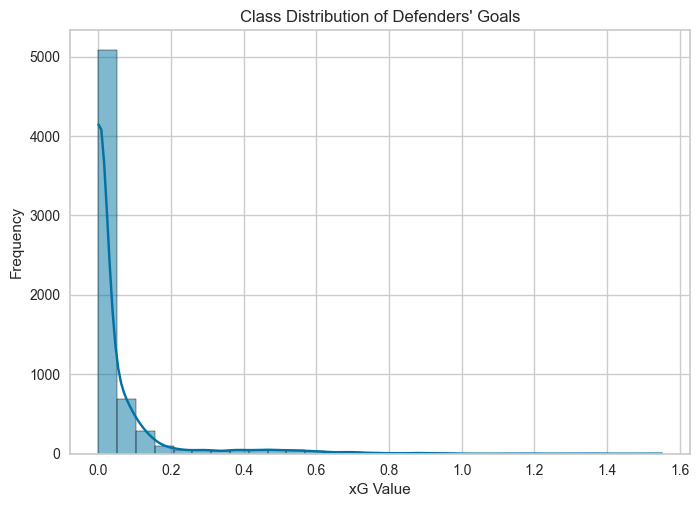

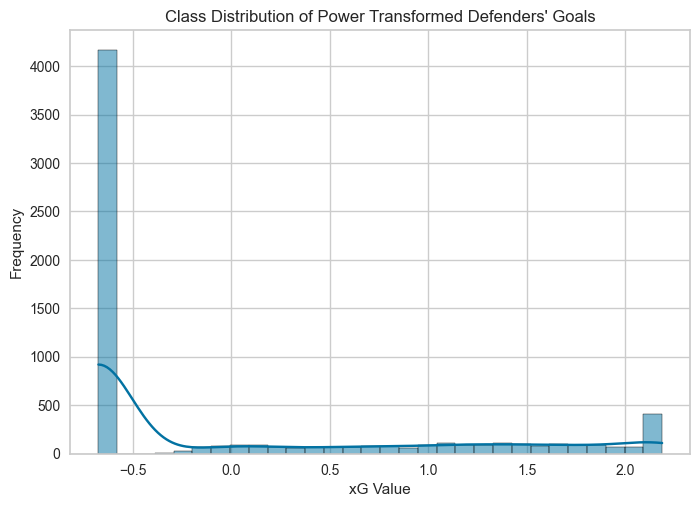

In [6]:
## TODO: XG PER 90????
def_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'DEF')]
def_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '2')]

def_xg_data = def_data[def_xg_features]
def_xg_data_tar = def_data_tar[def_xg_features]

def_data.reset_index(drop=True, inplace=True)
def_xg_data.reset_index(drop=True, inplace=True)

def_xg_data.drop(columns=['position'], inplace=True)
def_xg_data_tar.drop(columns=['xG', 'position'], inplace=True)

print(def_xg_data['xG'].value_counts())

sns.histplot(data=def_xg_data, x='xG', bins=30, kde=True) #countplot(x='xG', data=def_xg_data)
plt.title('Class Distribution of Defenders\' Goals')
plt.xlabel('xG Value')
plt.ylabel('Frequency')
plt.show()

pt_def_xg = PowerTransformer(method='yeo-johnson',  standardize=True)
pt_def_xg.fit(def_xg_data[['xG']])
joblib.dump(pt_def_xg, './models/pt_def_xg.pkl')  # Save fitted transformer

def_xg_data['xG'] = pt_def_xg.transform(def_xg_data[['xG']])


sns.histplot(data=def_xg_data, x='xG', bins=30, kde=True) #countplot(x='xG', data=def_xg_data)
plt.title('Class Distribution of Power Transformed Defenders\' Goals')
plt.xlabel('xG Value')
plt.ylabel('Frequency')
plt.show()

### Base Model


In [7]:
base_def_xg_model = setup(def_xg_data, target = 'xG',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features

                )

base_def_xg_best = base_def_xg_model.compare_models(sort='MAE', n_select=1)
base_def_xg_best

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 1.720167 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5432
[LightGBM] [Info] Number of data points in the train set: 5258, number of used features: 71
[LightGBM] [Info] Start training from score 0.007285


,Description,Value
0,Session id,5760
1,Target,xG
2,Target type,Regression
3,Original data shape,"(6573, 93)"
4,Transformed data shape,"(6573, 19)"
5,Transformed train set shape,"(5258, 19)"
6,Transformed test set shape,"(1315, 19)"
7,Numeric features,91
8,Rows with missing values,0.0%
9,Preprocess,True


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
rf,Random Forest Regressor,0.3196,0.2945,0.5418,0.7086,0.2421,2.0961,5.8100
et,Extra Trees Regressor,0.3213,0.2959,0.5431,0.7072,0.2445,2.1040,10.8630
lightgbm,Light Gradient Boosting Machine,0.3268,0.2965,0.5433,0.7068,0.2448,1.9606,3.0230
gbr,Gradient Boosting Regressor,0.3366,0.2979,0.5448,0.7052,0.2475,1.9530,2.6370
xgboost,Extreme Gradient Boosting,0.3583,0.3284,0.5717,0.6753,0.2522,2.0004,2.5480
ada,AdaBoost Regressor,0.3704,0.3255,0.5698,0.6779,0.2398,1.9014,1.9020
dt,Decision Tree Regressor,0.3968,0.5919,0.7684,0.4134,0.2701,2.0273,2.8000
knn,K Neighbors Regressor,0.4224,0.4429,0.6647,0.5621,0.2932,1.5733,2.2650
huber,Huber Regressor,0.4336,0.5157,0.7174,0.4899,0.3249,1.1819,2.1220
lr,Linear Regression,0.5152,0.4748,0.6885,0.5301,0.3536,1.3242,3.6050


RandomForestRegressor(n_jobs=-1, random_state=5760)

In [8]:
evaluate_model(base_def_xg_best)
# plot_model(base_fwd_y_best, plot='confusion_matrix')

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

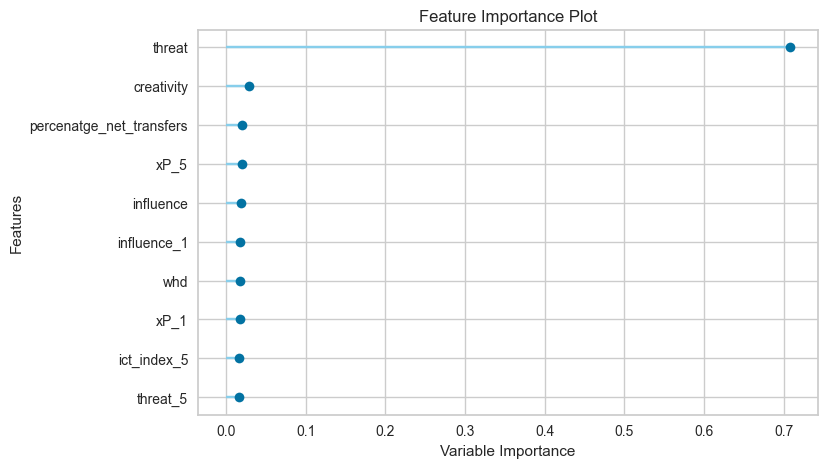

In [9]:
# plot_model(base_def_xg_best, plot='residuals')      # Residuals vs. predicted values
# plot_model(base_def_xg_best, plot='error')          # Prediction error plot
plot_model(base_def_xg_best, plot='feature')        # Feature importance

### Tune Model


In [10]:
def_xg_tuned = tune_model(base_def_xg_best, optimize='MAE')

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.3158,0.2739,0.5233,0.7097,0.2296,1.4230
1,0.3377,0.3031,0.5505,0.7049,0.2434,1.1027
2,0.3646,0.3711,0.6092,0.6292,0.2411,1.4082
3,0.3141,0.2652,0.5150,0.7402,0.2233,4.2290
4,0.3592,0.3304,0.5748,0.7019,0.2449,0.8448
5,0.3539,0.3353,0.5790,0.6543,0.2553,1.4635
6,0.3482,0.3319,0.5761,0.6392,0.2360,1.0340
7,0.3509,0.3189,0.5647,0.6805,0.2398,4.9668
8,0.3432,0.3361,0.5798,0.6804,0.2233,1.4609


Fitting 10 folds for each of 10 candidates, totalling 100 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


### Save Model


In [11]:
# Apply patch
# TransformerWrapper._reorder_cols = _reorder_cols
def_xg_final_model = finalize_model(base_def_xg_best)
save_model(def_xg_final_model, './models/def_xg_final_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'expected_assists_1',
                                              'expected_goal_involvements_1',
                                              'expected_goals_1',
                                              'goals_scored_1', 'ict_index_1',
                                              'influence_1', 'creativi...
                                     transformer=SimpleImputer(strategy='most_frequent'))),
                 ('remove_multicollinearity',
 

## Mid


In [12]:
mid_xg_features = [ 'position',  'xG', 'whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty', 'percenatge_net_transfers', 'ict_index', 'influence', 'creativity', 'threat',

            'expected_assists_1', 'expected_goal_involvements_1', 'expected_goals_1',  'goals_scored_1', 'ict_index_1', 'influence_1', 'creativity_1', 'threat_1', 'minutes_1',
            'red_cards_1', 'yellow_cards_1', 'starts_1', 'team_a_score_1', 'team_h_score_1', 'total_points_1', 'goals_1', 'shots_1', 'xG_1', 'xA_1', 'assists_x_1', 'assists_y_1',
            'key_passes_1', 'npg_1', 'npxG_1', 'xGChain_1', 'xGBuildup_1',  'xP_1',

            'expected_assists_3', 'expected_goal_involvements_3', 'expected_goals_3',  'goals_scored_3', 'ict_index_3', 'influence_3', 'creativity_3', 'threat_3', 'minutes_3',
            'red_cards_3', 'yellow_cards_3', 'starts_3', 'team_a_score_3', 'team_h_score_3', 'total_points_3', 'goals_3', 'shots_3', 'xG_3', 'xA_3', 'assists_x_3', 'assists_y_3',
            'key_passes_3', 'npg_3', 'npxG_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'expected_assists_5', 'expected_goal_involvements_5', 'expected_goals_5',  'goals_scored_5', 'ict_index_5', 'influence_5', 'creativity_5', 'threat_5', 'minutes_5',
            'red_cards_5', 'yellow_cards_5', 'starts_5', 'team_a_score_5', 'team_h_score_5', 'total_points_5', 'goals_5', 'shots_5', 'xG_5', 'xA_5', 'assists_x_5', 'assists_y_5',
            'key_passes_5', 'npg_5', 'npxG_5', 'xGChain_5', 'xGBuildup_5',  'xP_5'
]

xG
0.000000    2501
0.761169      11
0.761169       3
0.052510       2
0.423129       1
            ... 
0.103368       1
0.078944       1
0.051074       1
0.104148       1
0.036180       1
Name: count, Length: 4563, dtype: int64


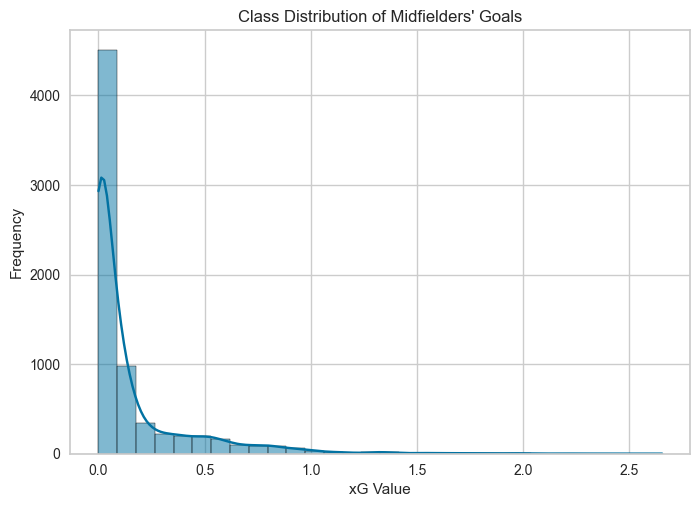

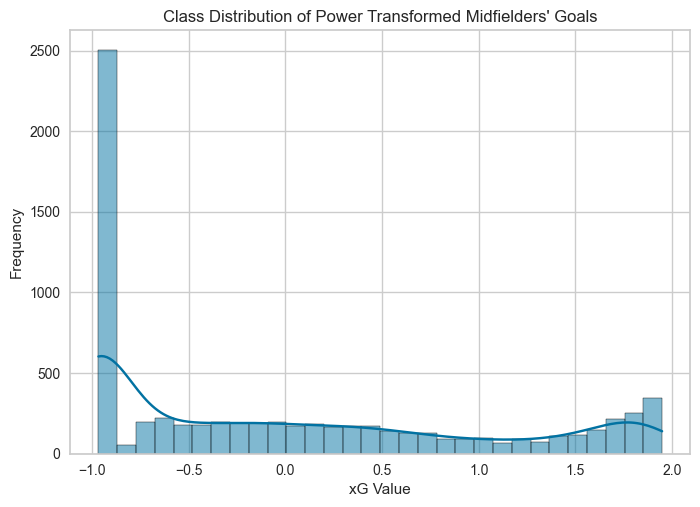

In [13]:

mid_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'MID')]
mid_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '3')]

mid_xg_data = mid_data[mid_xg_features]
mid_xg_data_tar = mid_data_tar[mid_xg_features]

mid_data.reset_index(drop=True, inplace=True)
mid_xg_data.reset_index(drop=True, inplace=True)

mid_xg_data.drop(columns=['position'], inplace=True)
mid_xg_data_tar.drop(columns=['xG', 'position'], inplace=True)

print(mid_xg_data['xG'].value_counts())

sns.histplot(data=mid_xg_data, x='xG', bins=30, kde=True) #countplot(x='xG', data=mid_xg_data)
plt.title('Class Distribution of Midfielders\' Goals')
plt.xlabel('xG Value')
plt.ylabel('Frequency')
plt.show()

pt_mid_xg = PowerTransformer(method='yeo-johnson',  standardize=True)
pt_mid_xg.fit(mid_xg_data[['xG']])
joblib.dump(pt_mid_xg, './models/pt_mid_xg.pkl')  # Save fitted transformer

mid_xg_data['xG'] = pt_mid_xg.transform(mid_xg_data[['xG']])


sns.histplot(data=mid_xg_data, x='xG', bins=30, kde=True) #countplot(x='xG', data=mid_xg_data)
plt.title('Class Distribution of Power Transformed Midfielders\' Goals')
plt.xlabel('xG Value')
plt.ylabel('Frequency')
plt.show()

### Base Model


In [14]:
base_mid_xg_model = setup(mid_xg_data, target = 'xG',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features

                )

base_mid_xg_best = base_mid_xg_model.compare_models(sort='MAE')
base_mid_xg_best

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010521 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6866
[LightGBM] [Info] Number of data points in the train set: 5660, number of used features: 72
[LightGBM] [Info] Start training from score 0.003343


,Description,Value
0,Session id,7436
1,Target,xG
2,Target type,Regression
3,Original data shape,"(7076, 93)"
4,Transformed data shape,"(7076, 19)"
5,Transformed train set shape,"(5660, 19)"
6,Transformed test set shape,"(1416, 19)"
7,Numeric features,91
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
rf,Random Forest Regressor,0.3622,0.2770,0.5261,0.7230,0.2627,26.5711,12.2500
et,Extra Trees Regressor,0.3650,0.2768,0.5259,0.7234,0.2607,33.1314,7.6320
gbr,Gradient Boosting Regressor,0.3682,0.2716,0.5208,0.7287,0.2595,26.3706,2.8710
lightgbm,Light Gradient Boosting Machine,0.3702,0.2813,0.5301,0.7189,0.2597,24.5722,9.2470
xgboost,Extreme Gradient Boosting,0.3965,0.3107,0.5570,0.6894,0.2673,19.8954,5.2110
ada,AdaBoost Regressor,0.4399,0.3152,0.5611,0.6853,0.2828,33.6077,2.0010
knn,K Neighbors Regressor,0.4542,0.3900,0.6241,0.6101,0.2888,23.8111,2.0680
huber,Huber Regressor,0.4648,0.4089,0.6390,0.5919,0.2911,30.5942,2.7010
dt,Decision Tree Regressor,0.4758,0.5365,0.7323,0.4635,0.3130,8.8811,1.8030
lr,Linear Regression,0.4806,0.3821,0.6178,0.6186,0.3030,24.1664,2.9910


RandomForestRegressor(n_jobs=-1, random_state=7436)

In [15]:
evaluate_model(base_mid_xg_best)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

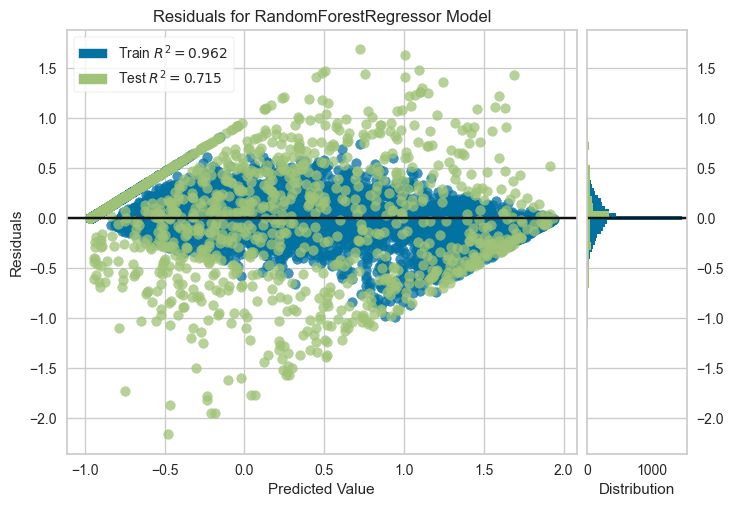

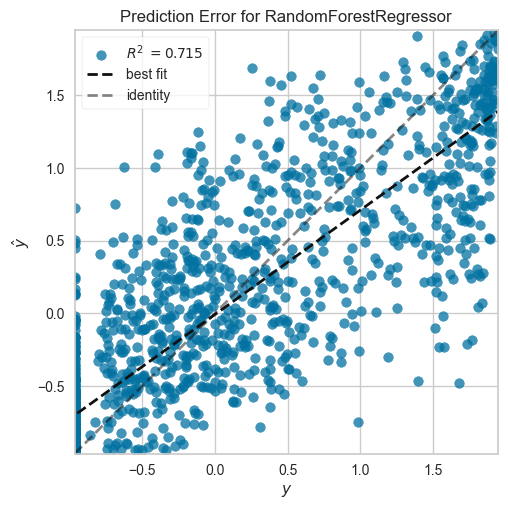

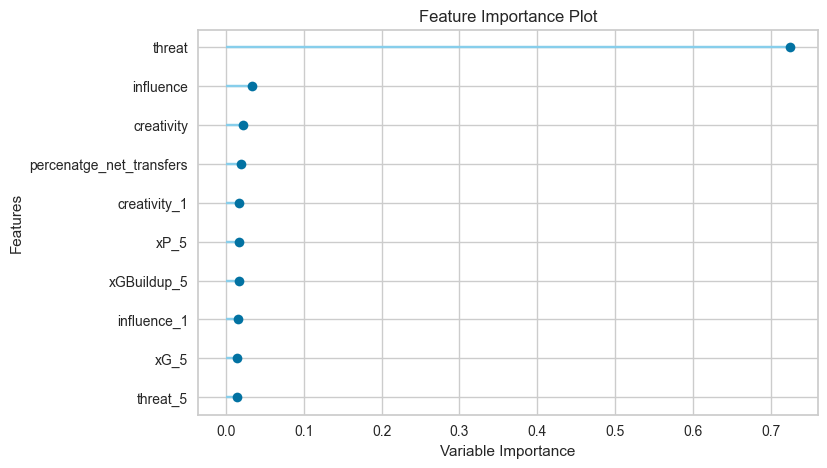

In [16]:
plot_model(base_mid_xg_best, plot='residuals')      # Residuals vs. predicted values
plot_model(base_mid_xg_best, plot='error')          # Prediction error plot
plot_model(base_mid_xg_best, plot='feature')        # Feature importance

### Tune Model


In [17]:
mid_xg_tuned = tune_model(base_mid_xg_best, optimize='MAE')

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.3792,0.3642,0.6035,0.6387,0.2671,1.7421
1,0.3564,0.3330,0.5770,0.6814,0.2596,1.9001
2,0.3767,0.3467,0.5888,0.6616,0.2698,1.3789
3,0.3635,0.3181,0.5640,0.6923,0.2697,1.6345
4,0.3781,0.3280,0.5727,0.6530,0.2749,1.4237
5,0.3703,0.3327,0.5768,0.6598,0.2569,1.4939
6,0.3610,0.3321,0.5763,0.6817,0.2655,1.1779
7,0.3739,0.3316,0.5758,0.6568,0.2732,2.7003
8,0.3305,0.2577,0.5077,0.7225,0.2408,358.0615


Fitting 10 folds for each of 10 candidates, totalling 100 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


### Save Model


In [18]:
mid_xg_final_model = finalize_model(base_mid_xg_best)
save_model(mid_xg_final_model, './models/mid_xg_final_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'expected_assists_1',
                                              'expected_goal_involvements_1',
                                              'expected_goals_1',
                                              'goals_scored_1', 'ict_index_1',
                                              'influence_1', 'creativi...
                                     transformer=SimpleImputer(strategy='most_frequent'))),
                 ('remove_multicollinearity',
 

## For


xG
0.000000    290
0.761169      7
0.208655      1
0.582700      1
0.366415      1
           ... 
0.583476      1
0.125661      1
1.442925      1
0.616388      1
0.326243      1
Name: count, Length: 1295, dtype: int64


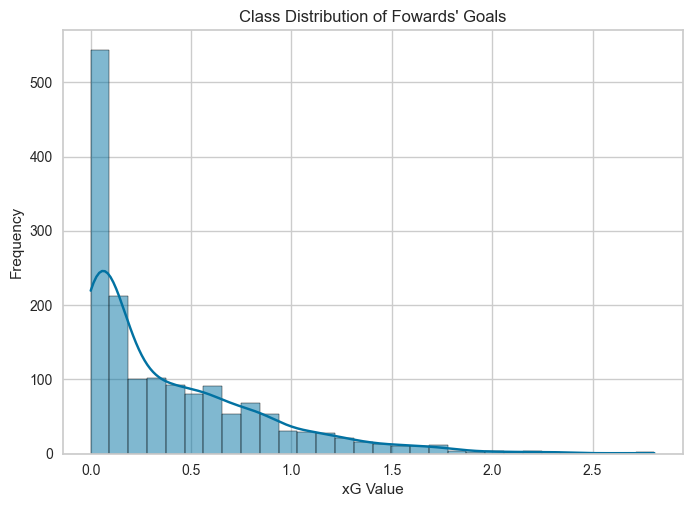

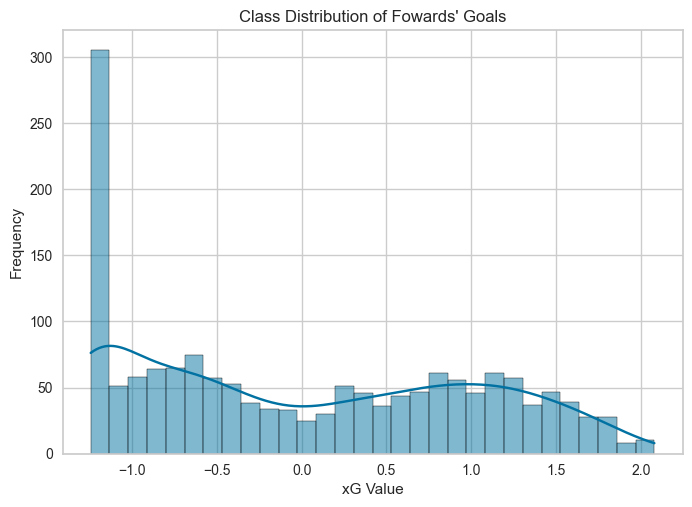

In [19]:
f_xg_features = [ 'position',  'xG', 'whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty', 'percenatge_net_transfers', 'ict_index', 'influence', 'creativity', 'threat',


            'expected_assists_1', 'expected_goal_involvements_1', 'expected_goals_1',  'goals_scored_1', 'ict_index_1', 'influence_1', 'creativity_1', 'threat_1', 'minutes_1',
            'red_cards_1', 'yellow_cards_1', 'starts_1', 'team_a_score_1', 'team_h_score_1', 'total_points_1', 'goals_1', 'shots_1', 'xG_1', 'xA_1', 'assists_x_1', 'assists_y_1',
            'key_passes_1', 'npg_1', 'npxG_1', 'xGChain_1', 'xGBuildup_1',  'xP_1',

            'expected_assists_3', 'expected_goal_involvements_3', 'expected_goals_3',  'goals_scored_3', 'ict_index_3', 'influence_3', 'creativity_3', 'threat_3', 'minutes_3',
            'red_cards_3', 'yellow_cards_3', 'starts_3', 'team_a_score_3', 'team_h_score_3', 'total_points_3', 'goals_3', 'shots_3', 'xG_3', 'xA_3', 'assists_x_3', 'assists_y_3',
            'key_passes_3', 'npg_3', 'npxG_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'expected_assists_5', 'expected_goal_involvements_5', 'expected_goals_5',  'goals_scored_5', 'ict_index_5', 'influence_5', 'creativity_5', 'threat_5', 'minutes_5',
            'red_cards_5', 'yellow_cards_5', 'starts_5', 'team_a_score_5', 'team_h_score_5', 'total_points_5', 'goals_5', 'shots_5', 'xG_5', 'xA_5', 'assists_x_5', 'assists_y_5',
            'key_passes_5', 'npg_5', 'npxG_5', 'xGChain_5', 'xGBuildup_5',  'xP_5'
]



fwd_xg_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'FWD')]
fwd_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '4')]

fwd_xg_data = fwd_xg_data[f_xg_features]
fwd_xg_data_tar = fwd_data_tar[f_xg_features]

fwd_xg_data.reset_index(drop=True, inplace=True)
fwd_xg_data.reset_index(drop=True, inplace=True)

fwd_xg_data.drop(columns=['position'], inplace=True)
fwd_xg_data_tar.drop(columns=['xG', 'position'], inplace=True)

print(fwd_xg_data['xG'].value_counts())

sns.histplot(data=fwd_xg_data, x='xG', bins=30, kde=True) #countplot(x='xG', data=fwd_xg_data)
plt.title('Class Distribution of Fowards\' Goals')
plt.xlabel('xG Value')
plt.ylabel('Frequency')
plt.show()

pt_fwd_xg = PowerTransformer(method='yeo-johnson',  standardize=True)
pt_fwd_xg.fit(fwd_xg_data[['xG']])
joblib.dump(pt_fwd_xg, './models/pt_fwd_xg.pkl')  # Save fitted transformer

fwd_xg_data['xG'] = pt_fwd_xg.transform(fwd_xg_data[['xG']])


sns.histplot(data=fwd_xg_data, x='xG', bins=30, kde=True) #countplot(x='xG', data=fwd_xg_data)
plt.title('Class Distribution of Fowards\' Goals')
plt.xlabel('xG Value')
plt.ylabel('Frequency')
plt.show()


### Base Model


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001998 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5227
[LightGBM] [Info] Number of data points in the train set: 1272, number of used features: 64
[LightGBM] [Info] Start training from score 0.001402


,Description,Value
0,Session id,4852
1,Target,xG
2,Target type,Regression
3,Original data shape,"(1590, 93)"
4,Transformed data shape,"(1590, 19)"
5,Transformed train set shape,"(1272, 19)"
6,Transformed test set shape,"(318, 19)"
7,Numeric features,91
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
rf,Random Forest Regressor,0.4479,0.3428,0.5833,0.6543,0.2771,1.2459,2.1430
et,Extra Trees Regressor,0.4517,0.3480,0.5879,0.6492,0.2779,1.1621,1.9850
gbr,Gradient Boosting Regressor,0.4519,0.3441,0.5841,0.6532,0.2747,1.2450,1.6830
lightgbm,Light Gradient Boosting Machine,0.4536,0.3514,0.5902,0.6463,0.2700,1.2490,1.4750
xgboost,Extreme Gradient Boosting,0.4747,0.3872,0.6201,0.6096,0.2785,1.3500,1.4830
knn,K Neighbors Regressor,0.4862,0.4079,0.6353,0.5878,0.2815,1.2585,0.9200
huber,Huber Regressor,0.5100,0.4275,0.6509,0.5696,0.2875,1.1259,0.8880
lr,Linear Regression,0.5156,0.3960,0.6268,0.6017,0.2993,1.0805,1.0010
ridge,Ridge Regression,0.5159,0.3958,0.6267,0.6018,0.2995,1.0824,0.9140
br,Bayesian Ridge,0.5191,0.4001,0.6304,0.5971,0.3018,1.0860,1.5670


RandomForestRegressor(n_jobs=-1, random_state=4852)
Évaluate the model...


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

Plots...


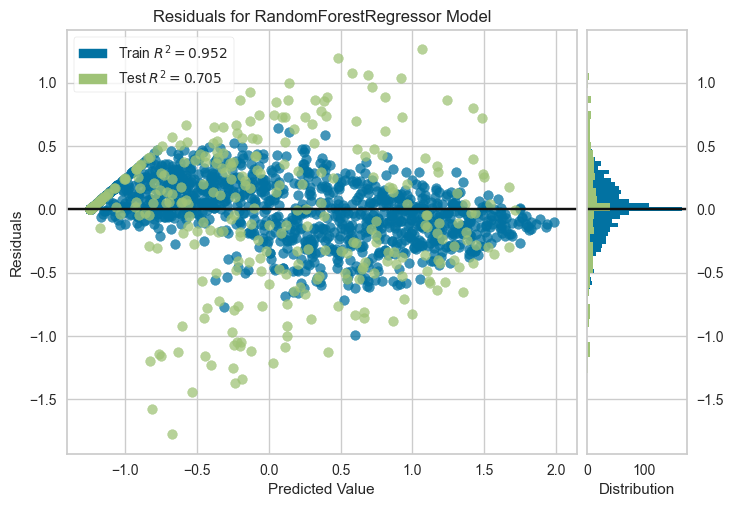

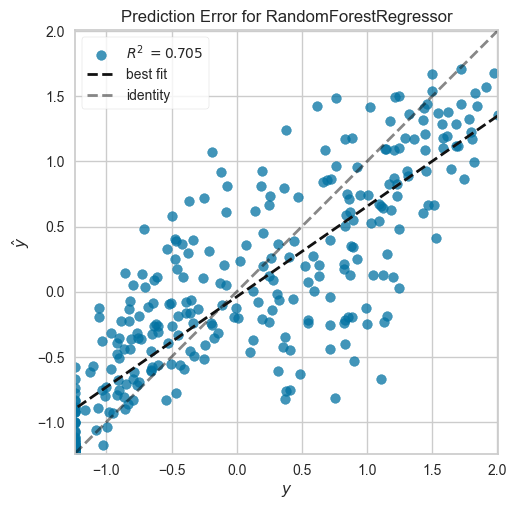

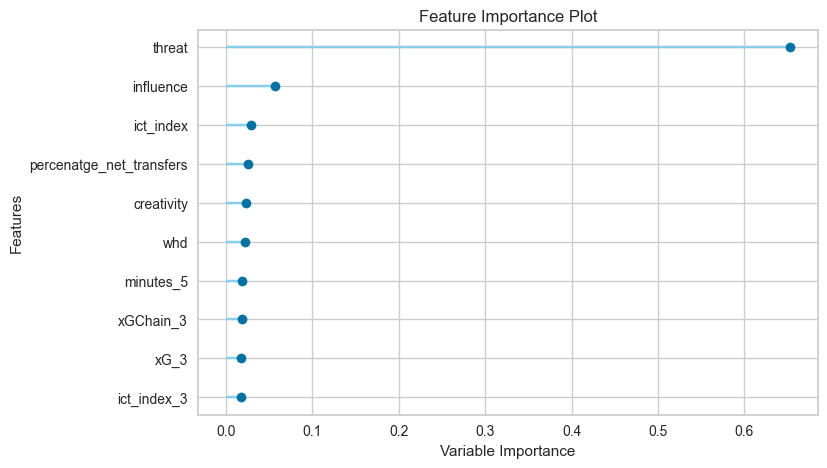

In [20]:
base_fwd_xg_model = setup(fwd_xg_data, target = 'xG',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features

                )

base_fwd_xg_best = base_fwd_xg_model.compare_models(sort='MAE', n_select=1)
print(base_fwd_xg_best)

print('Évaluate the model...')
evaluate_model(base_fwd_xg_best)

print('Plots...')
plot_model(base_fwd_xg_best, plot='residuals')      # Residuals vs. predicted values
plot_model(base_fwd_xg_best, plot='error')          # Prediction error plot
plot_model(base_fwd_xg_best, plot='feature')        # Feature importance



### Tune Model


In [21]:
tuned_fwd_xg_model = tune_model(base_fwd_xg_best, optimize='MAE')

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.4130,0.3271,0.5719,0.6536,0.2404,1.6437
1,0.3781,0.3201,0.5658,0.7313,0.2183,0.8980
2,0.5115,0.5456,0.7386,0.4925,0.2494,1.0785
3,0.4838,0.4777,0.6911,0.4956,0.2823,1.0673
4,0.4465,0.3857,0.6210,0.5952,0.2297,1.5347
5,0.4656,0.3979,0.6308,0.5941,0.2572,1.6604
6,0.4252,0.4171,0.6459,0.5679,0.2222,1.7784
7,0.4545,0.4127,0.6424,0.5638,0.2503,3.1614
8,0.4081,0.3623,0.6019,0.6095,0.2337,0.7812


Fitting 10 folds for each of 10 candidates, totalling 100 fits


### Save Model


In [22]:
fwd_xg_final_model = finalize_model(tuned_fwd_xg_model)
save_model(fwd_xg_final_model, './models/fwd_xg_final_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'expected_assists_1',
                                              'expected_goal_involvements_1',
                                              'expected_goals_1',
                                              'goals_scored_1', 'ict_index_1',
                                              'influence_1', 'creativi...
                 ('feature_selection',
                  TransformerWrapper(exclude=[],
                                     transformer=Se

# Assists


In [23]:
xa_features = [ 'position',  'xA', 'whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty', 'percenatge_net_transfers', 'ict_index', 'influence',
                 'creativity', 'threat','starts',

            'expected_assists_1', 'expected_goal_involvements_1', 'ict_index_1', 'influence_1', 'creativity_1', 'threat_1', 'minutes_1',
            'red_cards_1', 'yellow_cards_1', 'starts_1', 'team_a_score_1', 'team_h_score_1', 'total_points_1',  'shots_1','xA_1', 'assists_x_1', 'assists_y_1',
            'key_passes_1', 'xGChain_1', 'xGBuildup_1',  'xP_1',

            'expected_assists_3', 'expected_goal_involvements_3', 'ict_index_3', 'influence_3', 'creativity_3', 'threat_3', 'minutes_3',
            'red_cards_3', 'yellow_cards_3', 'starts_3', 'team_a_score_3', 'team_h_score_3', 'total_points_3', 'shots_3', 'xA_3', 'assists_x_3', 'assists_y_3',
            'key_passes_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'expected_assists_5', 'expected_goal_involvements_5', 'ict_index_5', 'influence_5', 'creativity_5', 'threat_5', 'minutes_5',
            'red_cards_5', 'yellow_cards_5', 'starts_5', 'team_a_score_5', 'team_h_score_5', 'total_points_5', 'shots_5',  'xA_5', 'assists_x_5', 'assists_y_5',
            'key_passes_5', 'xGChain_5', 'xGBuildup_5',  'xP_5'
]

## Def


xA
0.000000    4470
0.059942       2
0.063347       1
0.108050       1
0.049833       1
            ... 
0.016065       1
0.037171       1
0.023500       1
0.013137       1
0.549479       1
Name: count, Length: 2103, dtype: int64


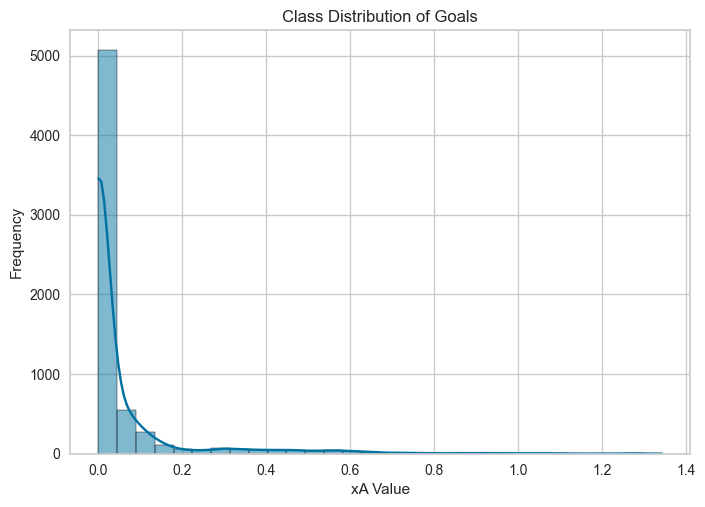

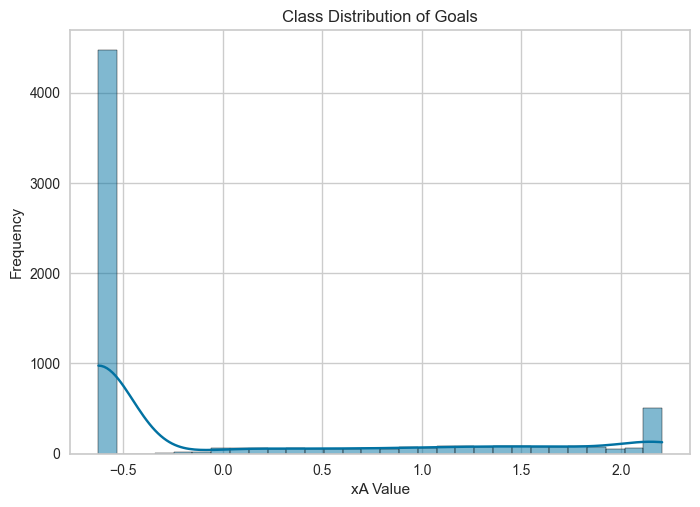

In [24]:
def_xa_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'DEF')]
def_xa_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '2')]

def_xa_data = def_xa_data[xa_features]
def_xa_data_tar = def_xa_data_tar[xa_features]

def_xa_data.reset_index(drop=True, inplace=True)
def_xa_data.reset_index(drop=True, inplace=True)

def_xa_data.drop(columns=['position'], inplace=True)
def_xa_data_tar.drop(columns=['xA', 'position'], inplace=True)

print(def_xa_data['xA'].value_counts())

sns.histplot(data=def_xa_data, x='xA', bins=30, kde=True) #countplot(x='xA', data=def_xa_data)
plt.title('Class Distribution of Goals')
plt.xlabel('xA Value')
plt.ylabel('Frequency')
plt.show()

pt_def_xa = PowerTransformer(method='yeo-johnson',  standardize=True)
pt_def_xa.fit(def_xa_data[['xA']])
joblib.dump(pt_def_xa, './models/pt_def_xa.pkl')  # Save fitted transformer

def_xa_data['xA'] = pt_def_xa.transform(def_xa_data[['xA']])


sns.histplot(data=def_xa_data, x='xA', bins=30, kde=True) #countplot(x='xA', data=def_xa_data)
plt.title('Class Distribution of Goals')
plt.xlabel('xA Value')
plt.ylabel('Frequency')
plt.show()

### Base Model


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.171453 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5677
[LightGBM] [Info] Number of data points in the train set: 5258, number of used features: 64
[LightGBM] [Info] Start training from score 0.002736


,Description,Value
0,Session id,3671
1,Target,xA
2,Target type,Regression
3,Original data shape,"(6573, 76)"
4,Transformed data shape,"(6573, 16)"
5,Transformed train set shape,"(5258, 16)"
6,Transformed test set shape,"(1315, 16)"
7,Numeric features,74
8,Rows with missing values,0.0%
9,Preprocess,True


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
rf,Random Forest Regressor,0.1969,0.1762,0.4195,0.8231,0.1856,0.8389,2.8220
et,Extra Trees Regressor,0.1991,0.1724,0.4150,0.8269,0.1855,0.8512,1.4280
gbr,Gradient Boosting Regressor,0.2025,0.1713,0.4135,0.8280,0.1839,0.8663,2.9510
lightgbm,Light Gradient Boosting Machine,0.2089,0.1820,0.4260,0.8175,0.1935,0.8633,2.7410
ada,AdaBoost Regressor,0.2103,0.1777,0.4212,0.8216,0.1866,0.8648,1.1280
xgboost,Extreme Gradient Boosting,0.2272,0.2018,0.4485,0.7977,0.2020,0.9755,1.7680
knn,K Neighbors Regressor,0.2316,0.2305,0.4791,0.7694,0.2196,0.8110,0.7860
dt,Decision Tree Regressor,0.2616,0.3440,0.5861,0.6543,0.2547,0.8725,1.0000
huber,Huber Regressor,0.3342,0.3808,0.6165,0.6179,0.2823,0.5220,0.9130
lr,Linear Regression,0.3923,0.3603,0.5998,0.6387,0.2863,0.6572,1.3130


RandomForestRegressor(n_jobs=-1, random_state=3671)
Évaluate the model...


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

Plots...


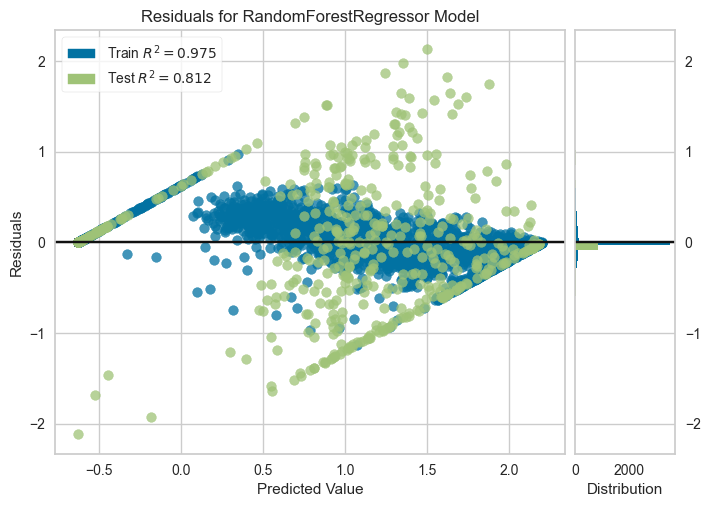

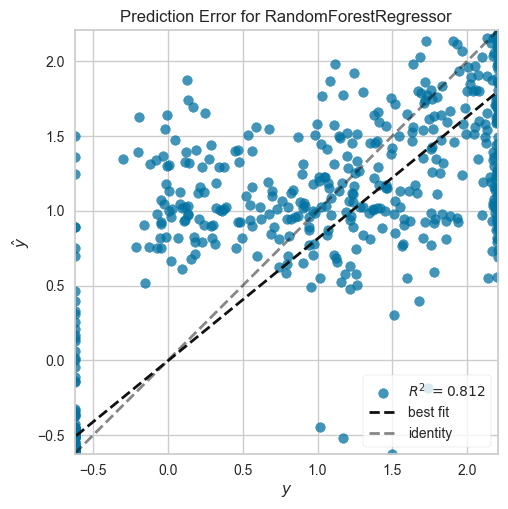

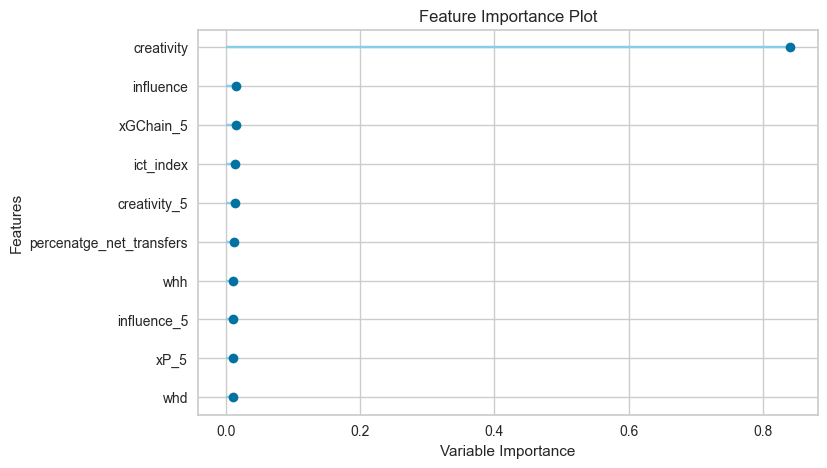

In [25]:
base_def_xa_model = setup(def_xa_data, target = 'xA',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features

                )

base_def_xa_best = base_def_xa_model.compare_models(sort='MAE', n_select=1)
print(base_def_xa_best)

print('Évaluate the model...')
evaluate_model(base_def_xa_best)

print('Plots...')
plot_model(base_def_xa_best, plot='residuals')      # Residuals vs. predicted values
plot_model(base_def_xa_best, plot='error')          # Prediction error plot
plot_model(base_def_xa_best, plot='feature')        # Feature importance



### Tune Model


In [26]:
def_xa_tuned = tune_model(base_def_xa_best, optimize='MAE')

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.2122,0.2283,0.4778,0.7449,0.1926,0.8554
1,0.2413,0.2258,0.4752,0.7785,0.2072,0.9033
2,0.2640,0.2525,0.5025,0.7519,0.2172,1.1608
3,0.2337,0.2112,0.4596,0.7782,0.2052,1.7105
4,0.2444,0.2300,0.4796,0.7920,0.2055,1.0513
5,0.2197,0.1918,0.4379,0.8092,0.1906,0.8091
6,0.2234,0.2034,0.4510,0.7847,0.2064,1.0906
7,0.2290,0.2113,0.4597,0.7919,0.1926,0.5912
8,0.2398,0.2217,0.4708,0.7822,0.2037,0.8622


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 10 folds for each of 10 candidates, totalling 100 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


### Save Model


In [27]:
def_xa_final_model = finalize_model(base_def_xa_best)
save_model(def_xa_final_model, './models/def_xa_final_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat', 'starts',
                                              'expected_assists_1',
                                              'expected_goal_involvements_1',
                                              'ict_index_1', 'influence_1',
                                              'creativity_1', 'threat_1',
                                              'minutes_1...
                                     transformer=SimpleImputer(strategy='most_frequent'))),
                 ('remove_multicollinearity',


## Mid


xA
0.000000    2859
0.107738       2
0.095407       1
0.023504       1
0.403232       1
            ... 
0.454983       1
0.081762       1
0.106337       1
0.115025       1
0.043413       1
Name: count, Length: 4217, dtype: int64


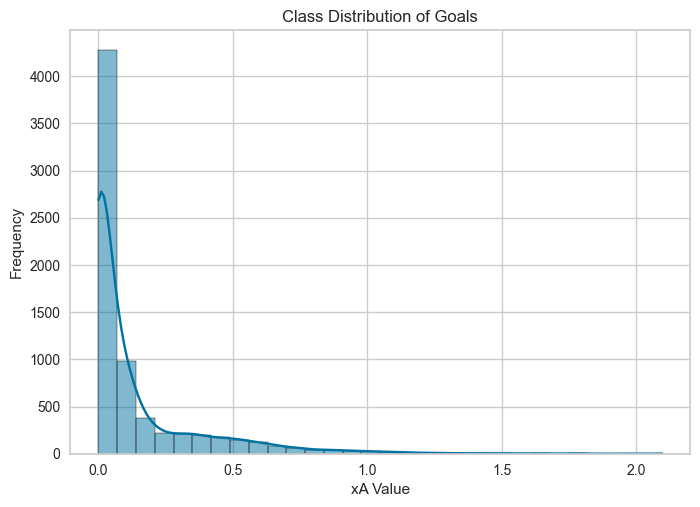

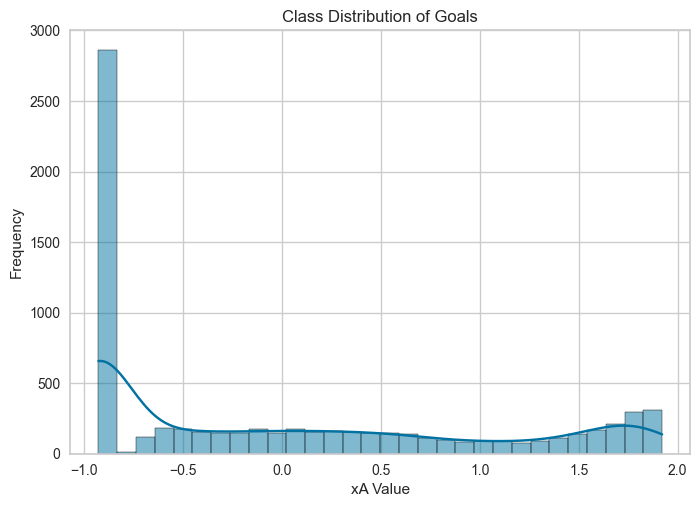

In [28]:

mid_xa_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'MID')]
mid_xa_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '3')]

mid_xa_data = mid_xa_data[xa_features]
mid_xa_data_tar = mid_xa_data_tar[xa_features]

mid_xa_data.reset_index(drop=True, inplace=True)
mid_xa_data.reset_index(drop=True, inplace=True)

mid_xa_data.drop(columns=['position'], inplace=True)
mid_xa_data_tar.drop(columns=['xA', 'position'], inplace=True)

print(mid_xa_data['xA'].value_counts())

sns.histplot(data=mid_xa_data, x='xA', bins=30, kde=True) #countplot(x='xA', data=mid_xa_data)
plt.title('Class Distribution of Goals')
plt.xlabel('xA Value')
plt.ylabel('Frequency')
plt.show()

pt_mid_xa = PowerTransformer(method='yeo-johnson',  standardize=True)
pt_mid_xa.fit(mid_xa_data[['xA']])
joblib.dump(pt_mid_xa, './models/pt_mid_xa.pkl')  # Save fitted transformer

mid_xa_data['xA'] = pt_mid_xa.transform(mid_xa_data[['xA']])


sns.histplot(data=mid_xa_data, x='xA', bins=30, kde=True) #countplot(x='xA', data=mid_xa_data)
plt.title('Class Distribution of Goals')
plt.xlabel('xA Value')
plt.ylabel('Frequency')
plt.show()

### Base model


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006187 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7009
[LightGBM] [Info] Number of data points in the train set: 5660, number of used features: 67
[LightGBM] [Info] Start training from score -0.002117


,Description,Value
0,Session id,7031
1,Target,xA
2,Target type,Regression
3,Original data shape,"(7076, 76)"
4,Transformed data shape,"(7076, 16)"
5,Transformed train set shape,"(5660, 16)"
6,Transformed test set shape,"(1416, 16)"
7,Numeric features,74
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
rf,Random Forest Regressor,0.3450,0.2926,0.5407,0.7059,0.2627,1.4637,5.4420
et,Extra Trees Regressor,0.3499,0.2944,0.5424,0.7039,0.2646,1.4268,3.1250
gbr,Gradient Boosting Regressor,0.3508,0.2870,0.5353,0.7117,0.2706,1.3920,2.1280
lightgbm,Light Gradient Boosting Machine,0.3541,0.2974,0.5449,0.7011,0.2640,1.5267,3.3870
ada,AdaBoost Regressor,0.3803,0.3123,0.5585,0.6861,0.2463,1.7145,1.7310
xgboost,Extreme Gradient Boosting,0.3911,0.3417,0.5843,0.6564,0.2728,1.8073,1.5810
knn,K Neighbors Regressor,0.3973,0.3664,0.6049,0.6317,0.2816,1.6338,1.7520
huber,Huber Regressor,0.4215,0.4092,0.6390,0.5893,0.2916,1.2251,1.5960
dt,Decision Tree Regressor,0.4445,0.5503,0.7413,0.4468,0.3072,2.4385,1.8330
lr,Linear Regression,0.4595,0.3887,0.6229,0.6098,0.3080,1.1850,2.3550


RandomForestRegressor(n_jobs=-1, random_state=7031)
Évaluate the model...


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

Plots...


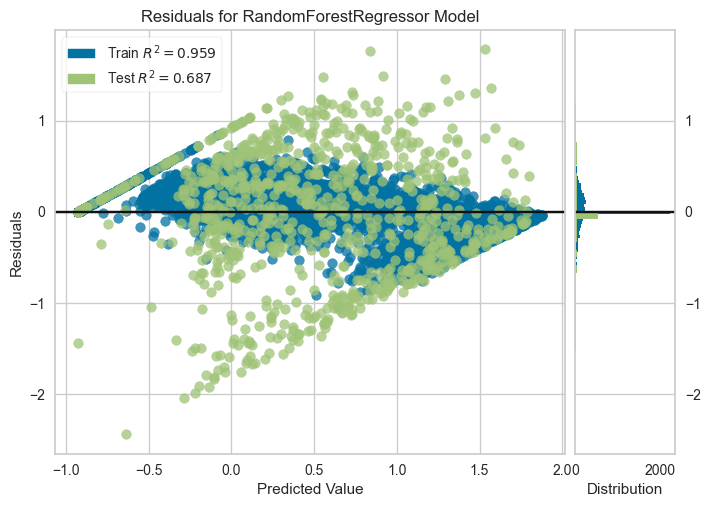

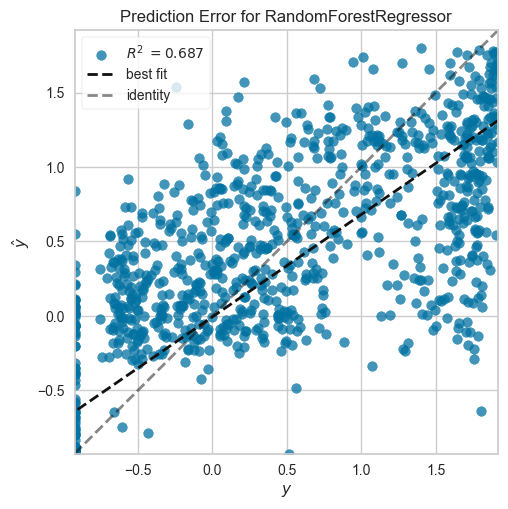

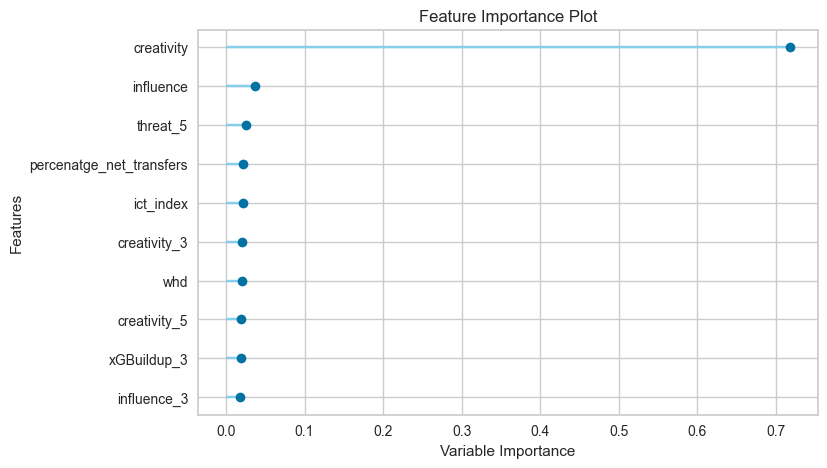

In [29]:
base_mid_xa_model = setup(mid_xa_data, target = 'xA',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features

                )

base_mid_xa_best = base_mid_xa_model.compare_models(sort='MAE', n_select=1)
print(base_mid_xa_best)

print('Évaluate the model...')
evaluate_model(base_mid_xa_best)

print('Plots...')
plot_model(base_mid_xa_best, plot='residuals')      # Residuals vs. predicted values
plot_model(base_mid_xa_best, plot='error')          # Prediction error plot
plot_model(base_mid_xa_best, plot='feature')        # Feature importance



### Tune model


In [30]:
mid_xa_tuned = tune_model(base_mid_xa_best, optimize='MAE')

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.3279,0.2929,0.5412,0.7157,0.2810,1.3712
1,0.3178,0.2698,0.5195,0.7115,0.2619,1.1558
2,0.3448,0.3463,0.5885,0.6468,0.2721,1.8472
3,0.3601,0.3696,0.6079,0.6476,0.2982,0.9842
4,0.3549,0.3623,0.6019,0.6311,0.2837,1.3242
5,0.3203,0.2827,0.5317,0.7085,0.2736,1.4482
6,0.3292,0.3221,0.5675,0.6592,0.2733,1.6144
7,0.3684,0.3586,0.5989,0.6389,0.2890,1.6564
8,0.3455,0.3475,0.5895,0.6738,0.2868,1.8661


Fitting 10 folds for each of 10 candidates, totalling 100 fits


### Save Model


In [31]:
mid_xa_final_model = finalize_model(base_mid_xa_best)
save_model(mid_xa_final_model, './models/mid_xa_final_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat', 'starts',
                                              'expected_assists_1',
                                              'expected_goal_involvements_1',
                                              'ict_index_1', 'influence_1',
                                              'creativity_1', 'threat_1',
                                              'minutes_1...
                                     transformer=SimpleImputer(strategy='most_frequent'))),
                 ('remove_multicollinearity',


## For


xA
0.000000    767
0.127663      1
0.077458      1
0.147103      1
0.733360      1
           ... 
0.414716      1
0.122116      1
0.031267      1
0.401950      1
0.048869      1
Name: count, Length: 824, dtype: int64


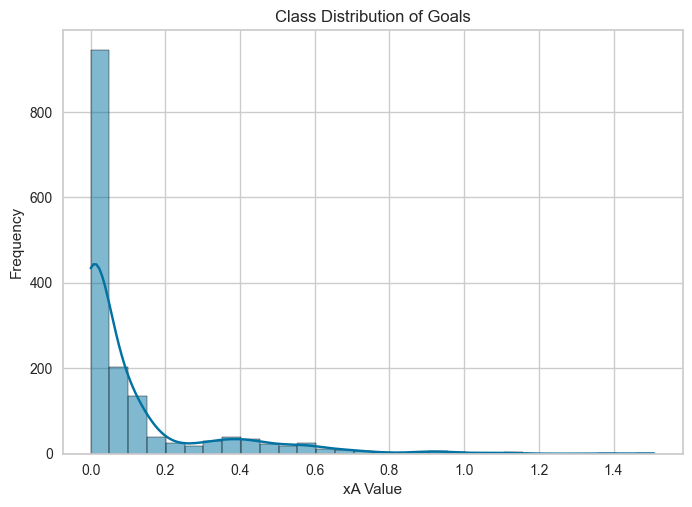

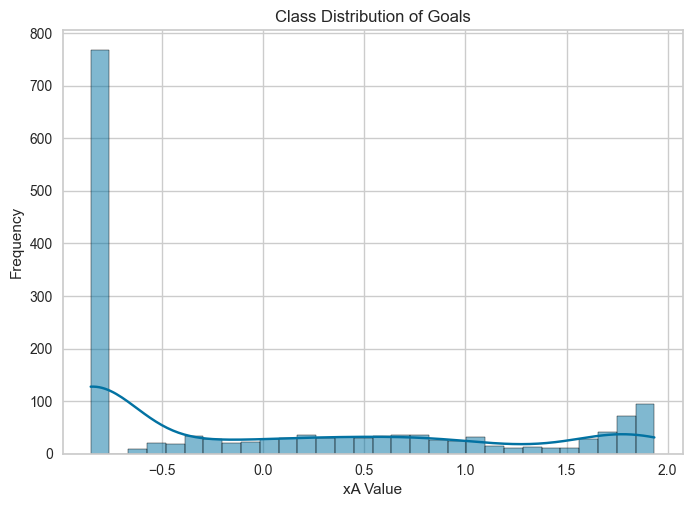

In [32]:

fwd_xa_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'FWD')]
fwd_xa_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '4')]

fwd_xa_data = fwd_xa_data[xa_features]
fwd_xa_data_tar = fwd_xa_data_tar[xa_features]

fwd_xa_data.reset_index(drop=True, inplace=True)
fwd_xa_data.reset_index(drop=True, inplace=True)

fwd_xa_data.drop(columns=['position'], inplace=True)
fwd_xa_data_tar.drop(columns=['xA', 'position'], inplace=True)



print(fwd_xa_data['xA'].value_counts())

sns.histplot(data=fwd_xa_data, x='xA', bins=30, kde=True) #countplot(x='xA', data=fwd_xa_data)
plt.title('Class Distribution of Goals')
plt.xlabel('xA Value')
plt.ylabel('Frequency')
plt.show()

pt_fwd_xa = PowerTransformer(method='yeo-johnson',  standardize=True)
pt_fwd_xa.fit(fwd_xa_data[['xA']])
joblib.dump(pt_fwd_xa, './models/pt_fwd_xa.pkl')  # Save fitted transformer

fwd_xa_data['xA'] = pt_fwd_xa.transform(fwd_xa_data[['xA']])


sns.histplot(data=fwd_xa_data, x='xA', bins=30, kde=True) #countplot(x='xA', data=fwd_xa_data)
plt.title('Class Distribution of Goals')
plt.xlabel('xA Value')
plt.ylabel('Frequency')
plt.show()

### Base model


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002411 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6349
[LightGBM] [Info] Number of data points in the train set: 1272, number of used features: 65
[LightGBM] [Info] Start training from score -0.024254


,Description,Value
0,Session id,8038
1,Target,xA
2,Target type,Regression
3,Original data shape,"(1590, 76)"
4,Transformed data shape,"(1590, 16)"
5,Transformed train set shape,"(1272, 16)"
6,Transformed test set shape,"(318, 16)"
7,Numeric features,74
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
rf,Random Forest Regressor,0.3215,0.2913,0.5382,0.7040,0.2418,1.1833,1.3400
et,Extra Trees Regressor,0.3230,0.2836,0.5313,0.7111,0.2390,1.1105,1.1510
gbr,Gradient Boosting Regressor,0.3344,0.2855,0.5327,0.7097,0.2372,1.1103,1.1400
lightgbm,Light Gradient Boosting Machine,0.3518,0.3089,0.5547,0.6858,0.2469,1.2900,0.7360
xgboost,Extreme Gradient Boosting,0.3581,0.3305,0.5729,0.6638,0.2603,1.2945,1.1280
dt,Decision Tree Regressor,0.3941,0.5071,0.7101,0.4856,0.2961,1.5033,0.7250
ada,AdaBoost Regressor,0.4026,0.3063,0.5517,0.6877,0.2374,1.3411,0.6980
huber,Huber Regressor,0.4040,0.4040,0.6341,0.5895,0.3064,0.7953,0.7080
knn,K Neighbors Regressor,0.4295,0.4266,0.6519,0.5650,0.2908,1.0856,0.9010
ridge,Ridge Regression,0.4431,0.3868,0.6207,0.6070,0.3149,0.8620,0.6830


RandomForestRegressor(n_jobs=-1, random_state=8038)
Évaluate the model...


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

Plots...


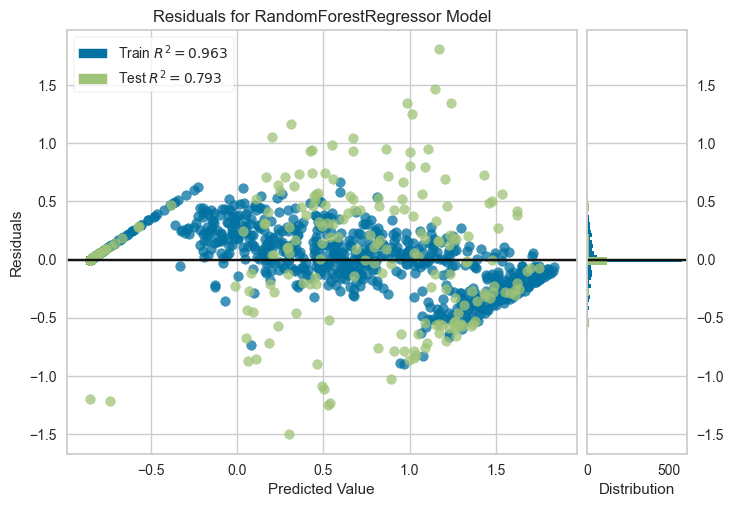

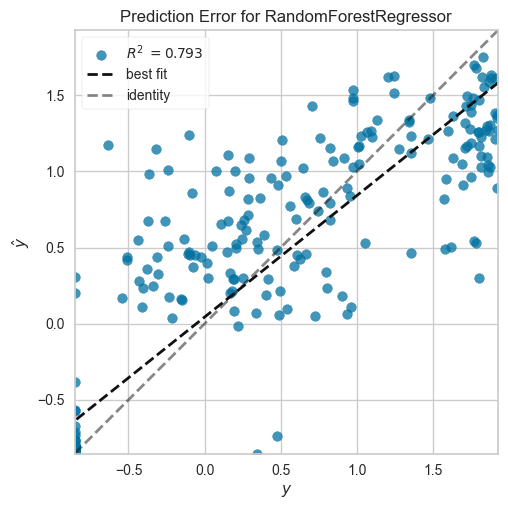

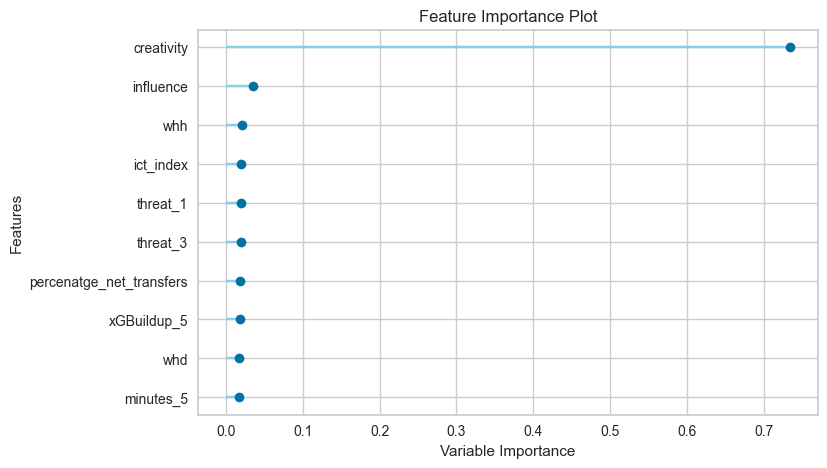

In [33]:
base_fwd_xa_model = setup(fwd_xa_data, target = 'xA',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features

                )

base_fwd_xa_best = base_fwd_xa_model.compare_models(sort='MAE', n_select=1)
print(base_fwd_xa_best)

print('Évaluate the model...')
evaluate_model(base_fwd_xa_best)

print('Plots...')
plot_model(base_fwd_xa_best, plot='residuals')      # Residuals vs. predicted values
plot_model(base_fwd_xa_best, plot='error')          # Prediction error plot
plot_model(base_fwd_xa_best, plot='feature')        # Feature importance

### Tune model


In [34]:
fwd_xa_tuned = tune_model(base_fwd_xa_best, optimize='MAE')

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.3448,0.3709,0.6090,0.6076,0.2706,1.0927
1,0.3509,0.3543,0.5952,0.6608,0.2818,0.7649
2,0.2961,0.3073,0.5544,0.6994,0.2146,0.4200
3,0.3713,0.3663,0.6052,0.6545,0.2943,2.9142
4,0.2698,0.2272,0.4767,0.7541,0.2247,0.9965
5,0.2997,0.2788,0.5281,0.6833,0.2212,0.7970
6,0.3084,0.3703,0.6086,0.6316,0.2519,0.8794
7,0.3267,0.3174,0.5634,0.6863,0.2525,0.8863
8,0.3145,0.3051,0.5524,0.7063,0.2726,0.9954


Fitting 10 folds for each of 10 candidates, totalling 100 fits


### Save Model


In [35]:
fwd_xa_final_model = finalize_model(base_fwd_xa_best)
save_model(fwd_xa_final_model, './models/fwd_xa_final_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat', 'starts',
                                              'expected_assists_1',
                                              'expected_goal_involvements_1',
                                              'ict_index_1', 'influence_1',
                                              'creativity_1', 'threat_1',
                                              'minutes_1...
                                     transformer=SimpleImputer(strategy='most_frequent'))),
                 ('remove_multicollinearity',


# Saves


## GK


saves
2     360
3     298
1     255
4     235
5     156
0     126
6      84
7      54
8      21
9      15
10      4
11      2
12      1
13      1
Name: count, dtype: int64


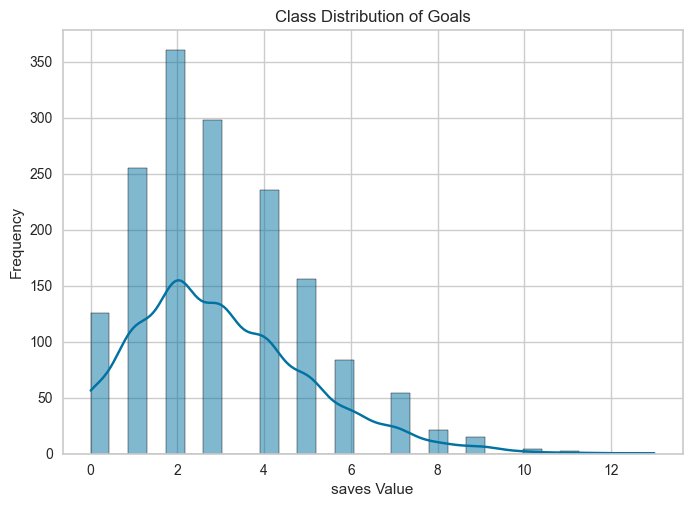

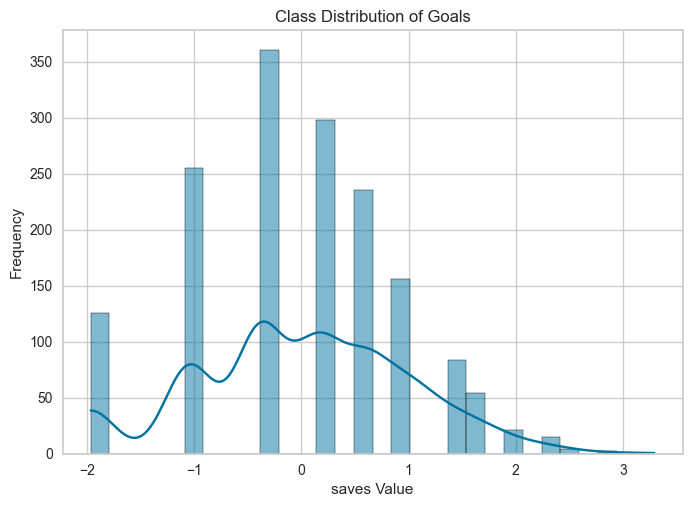

In [36]:
saves_features = ['position', 'whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty', 'ownership_change', 'percenatge_net_transfers',
            'saves',  'ict_index', 'influence', 'creativity', 'threat',

            'clean_sheets_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'goals_scored_1', 'ict_index_1',
            'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1', 'penalties_saved_1',  'yellow_cards_1', 'saves_1', 'starts_1',
            'team_a_score_1', 'team_h_score_1', 'total_points_1', 'xGChain_1', 'xGBuildup_1', 'xP_1',

            'clean_sheets_3', 'expected_goals_3', 'expected_goals_conceded_3', 'goals_conceded_3', 'ict_index_3',
            'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_goals_3', 'penalties_saved_3', 'red_cards_3', 'yellow_cards_3', 'saves_3', 'starts_3',
            'team_a_score_3', 'team_h_score_3', 'total_points_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'clean_sheets_5', 'expected_goals_5', 'expected_goals_conceded_5', 'goals_conceded_5', 'ict_index_5',
            'influence_5', 'creativity_5', 'threat_5', 'minutes_5', 'own_goals_5', 'penalties_saved_5', 'red_cards_5', 'yellow_cards_5', 'saves_5', 'starts_5',
            'team_a_score_5', 'team_h_score_5', 'total_points_5',  'xGChain_5', 'xGBuildup_5',  'xP_5'
                        ]



g_saves_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'GK')]
g_saves_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '1')]

g_saves_data = g_saves_data[saves_features]
g_saves_data_tar = g_saves_data_tar[saves_features]

g_saves_data.reset_index(drop=True, inplace=True)
g_saves_data.reset_index(drop=True, inplace=True)

g_saves_data.drop(columns=['position'], inplace=True)
g_saves_data_tar.drop(columns=['position', 'saves'], inplace=True)

print(g_saves_data['saves'].value_counts())

sns.histplot(data=g_saves_data, x='saves', bins=30, kde=True) #countplot(x='saves', data=g_saves_data)
plt.title('Class Distribution of Goals')
plt.xlabel('saves Value')
plt.ylabel('Frequency')
plt.show()

pt_gk_saves = PowerTransformer(method='yeo-johnson',  standardize=True)
pt_gk_saves.fit(g_saves_data[['saves']])
joblib.dump(pt_gk_saves, './models/pt_gk_saves.pkl')  # Save fitted transformer

g_saves_data['saves'] = pt_gk_saves.transform(g_saves_data[['saves']])


sns.histplot(data=g_saves_data, x='saves', bins=30, kde=True) #countplot(x='saves', data=g_saves_data)
plt.title('Class Distribution of Goals')
plt.xlabel('saves Value')
plt.ylabel('Frequency')
plt.show()

### Base Model


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.078484 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3077
[LightGBM] [Info] Number of data points in the train set: 1289, number of used features: 53
[LightGBM] [Info] Start training from score -0.001763


,Description,Value
0,Session id,8068
1,Target,saves
2,Target type,Regression
3,Original data shape,"(1612, 75)"
4,Transformed data shape,"(1612, 15)"
5,Transformed train set shape,"(1289, 15)"
6,Transformed test set shape,"(323, 15)"
7,Numeric features,73
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
gbr,Gradient Boosting Regressor,0.2813,0.1487,0.3850,0.8492,0.1915,0.6392,0.7780
rf,Random Forest Regressor,0.2892,0.1549,0.3925,0.8424,0.1954,0.6579,1.3390
et,Extra Trees Regressor,0.2919,0.1559,0.3937,0.8412,0.1968,0.6609,0.8900
lightgbm,Light Gradient Boosting Machine,0.2975,0.1623,0.4015,0.8349,0.2023,0.6949,1.6840
xgboost,Extreme Gradient Boosting,0.3069,0.1770,0.4190,0.8197,0.2092,0.7081,0.9680
ridge,Ridge Regression,0.3180,0.1848,0.4277,0.8129,0.2057,0.6779,1.1390
lr,Linear Regression,0.3182,0.1850,0.4279,0.8127,0.2058,0.6786,1.2610
lar,Least Angle Regression,0.3184,0.1850,0.4280,0.8127,0.2058,0.6793,1.6080
br,Bayesian Ridge,0.3189,0.1857,0.4286,0.8120,0.2052,0.6803,0.7690
en,Elastic Net,0.3242,0.1891,0.4332,0.8083,0.2075,0.6785,0.7480


GradientBoostingRegressor(random_state=8068)
Évaluate the model...


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

Plots...


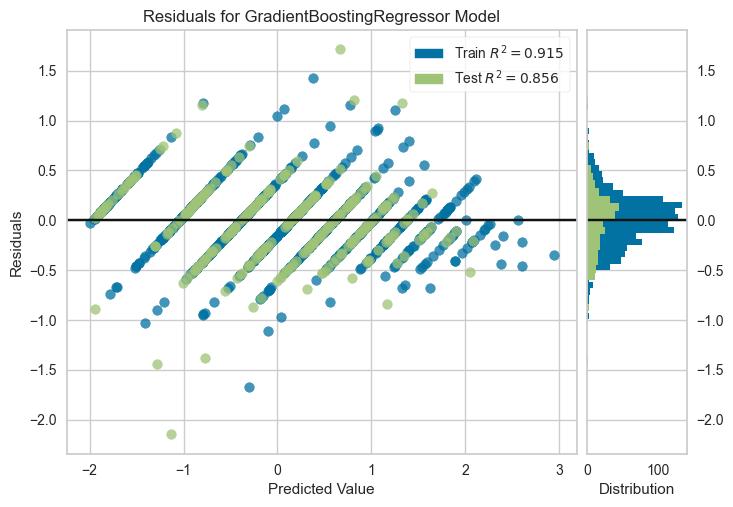

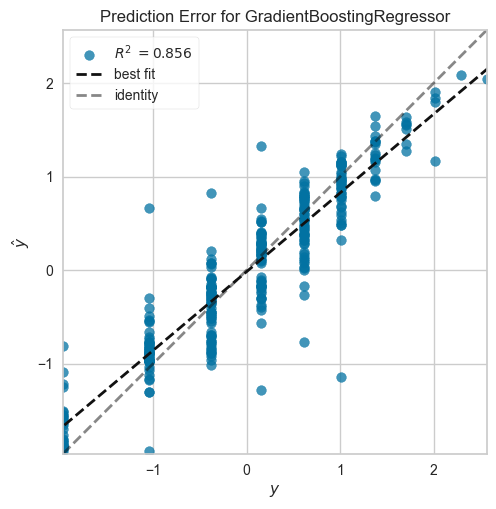

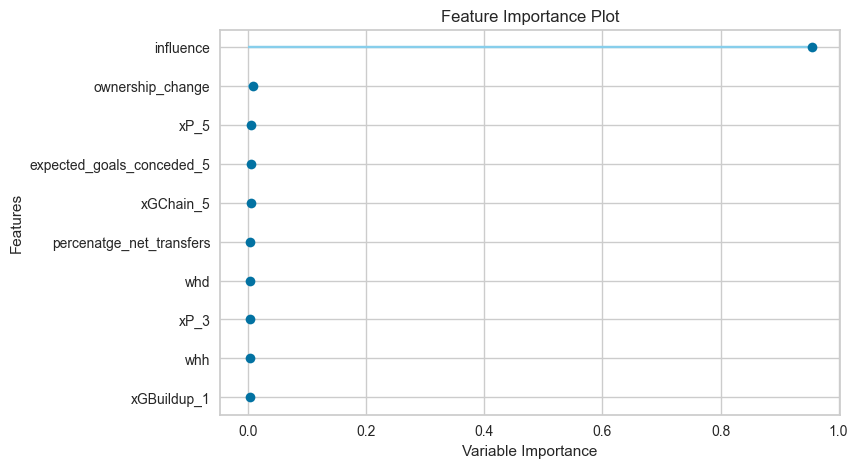

In [37]:
base_g_saves_model = setup(g_saves_data, target = 'saves',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features

                )

base_g_saves_best = base_g_saves_model.compare_models(sort='MAE', n_select=1)
print(base_g_saves_best)

print('Évaluate the model...')
evaluate_model(base_g_saves_best)

print('Plots...')
plot_model(base_g_saves_best, plot='residuals')      # Residuals vs. predicted values
plot_model(base_g_saves_best, plot='error')          # Prediction error plot
plot_model(base_g_saves_best, plot='feature')        # Feature importance

### Tune Model


In [38]:
g_saves_tuned = tune_model(base_g_saves_best, optimize='MAE')

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.2610,0.1280,0.3578,0.8618,0.1868,0.6384
1,0.2928,0.1698,0.4121,0.8164,0.1768,0.5859
2,0.2880,0.1560,0.3950,0.8528,0.1830,0.4949
3,0.2812,0.1601,0.4001,0.8466,0.1887,0.5942
4,0.2626,0.1248,0.3532,0.8691,0.1965,0.6254
5,0.2988,0.1543,0.3928,0.8832,0.1840,0.6649
6,0.2953,0.1593,0.3991,0.8075,0.2034,0.7680
7,0.2676,0.1170,0.3420,0.8943,0.1784,0.5357
8,0.2831,0.1455,0.3814,0.8364,0.1941,0.6277


Fitting 10 folds for each of 10 candidates, totalling 100 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


### Save Model


In [39]:
g_saves_final_model = finalize_model(base_g_saves_best)
save_model(g_saves_final_model, './models/g_saves_final_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'ownership_change',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'clean_sheets_1',
                                              'expected_goals_conceded_1',
                                              'goals_conceded_1',
                                              'goals_scored_1', 'ict_index_1',
                                              'influence_...
                                     transformer=SimpleImputer(strategy='most_frequent'))),
 

# Goals Conceded


In [40]:
xgc_features = [ 'position', 'whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty',  'ownership_change', 'percenatge_net_transfers',
            'expected_goals_conceded',  'ict_index', 'influence', 'creativity', 'threat',

            'clean_sheets_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'ict_index_1',
            'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1', 'penalties_saved_1', 'yellow_cards_1', 'saves_1', 'starts_1',
            'team_a_score_1', 'team_h_score_1', 'total_points_1', 'xGChain_1', 'xGBuildup_1', 'xP_1',

            'clean_sheets_3',  'expected_goals_conceded_3', 'goals_conceded_3', 'ict_index_3',
            'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_goals_3', 'penalties_saved_3', 'yellow_cards_3', 'saves_3', 'starts_3',
            'team_a_score_3', 'team_h_score_3', 'total_points_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'clean_sheets_5', 'expected_goals_conceded_5', 'goals_conceded_5', 'ict_index_5',
            'influence_5', 'creativity_5', 'threat_5', 'minutes_5', 'own_goals_5', 'penalties_saved_5', 'yellow_cards_5', 'saves_5', 'starts_5',
            'team_a_score_5', 'team_h_score_5', 'total_points_5',  'xGChain_5', 'xGBuildup_5',  'xP_5'
                        ]

## GK


expected_goals_conceded
1.48    19
0.83    17
1.03    14
1.32    13
1.12    13
        ..
3.22     1
2.62     1
3.52     1
3.70     1
3.60     1
Name: count, Length: 344, dtype: int64


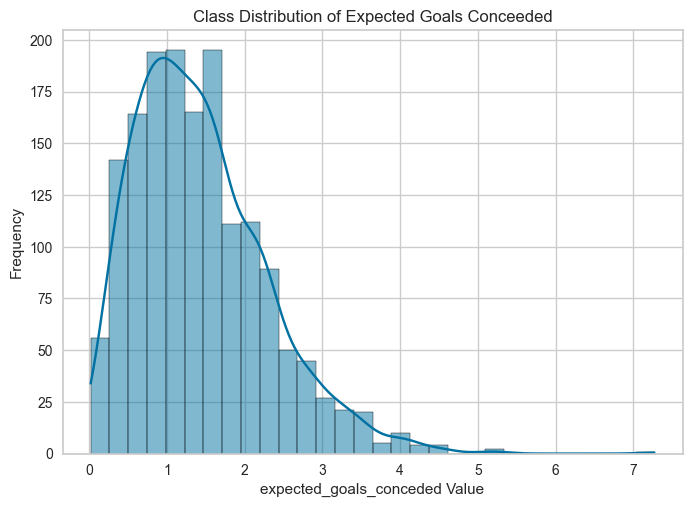

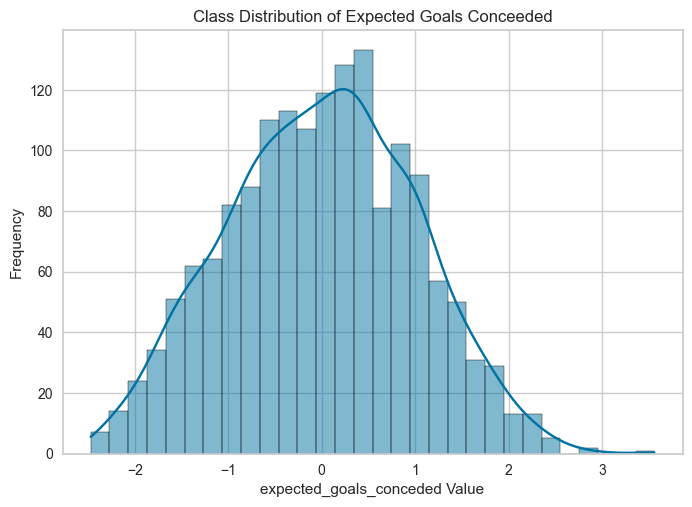

In [41]:
g_xgc_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'GK')]
g_xgc_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '1')]

g_xgc_data = g_xgc_data[xgc_features]
g_xgc_data_tar = g_xgc_data_tar[xgc_features]

g_xgc_data.reset_index(drop=True, inplace=True)
g_xgc_data.reset_index(drop=True, inplace=True)

g_xgc_data.drop(columns=['position'], inplace=True)
g_xgc_data_tar.drop(columns=['position', 'expected_goals_conceded'], inplace=True)

print(g_xgc_data['expected_goals_conceded'].value_counts())

sns.histplot(data=g_xgc_data, x='expected_goals_conceded', bins=30, kde=True) #countplot(x='expected_goals_conceded', data=g_xgc_data)
plt.title('Class Distribution of Expected Goals Conceeded')
plt.xlabel('expected_goals_conceded Value')
plt.ylabel('Frequency')
plt.show()

pt_gk_xgc = PowerTransformer(method='yeo-johnson',  standardize=True)
pt_gk_xgc.fit(g_xgc_data[['expected_goals_conceded']])
joblib.dump(pt_gk_xgc, './models/pt_gk_xgc.pkl')  # Save fitted transformer

g_xgc_data['expected_goals_conceded'] = pt_gk_xgc.transform(g_xgc_data[['expected_goals_conceded']])


sns.histplot(data=g_xgc_data, x='expected_goals_conceded', bins=30, kde=True) #countplot(x='expected_goals_conceded', data=g_xgc_data)
plt.title('Class Distribution of Expected Goals Conceeded')
plt.xlabel('expected_goals_conceded Value')
plt.ylabel('Frequency')
plt.show()

### Base Model


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003092 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3085
[LightGBM] [Info] Number of data points in the train set: 1289, number of used features: 53
[LightGBM] [Info] Start training from score 0.004059


,Description,Value
0,Session id,3833
1,Target,expected_goals_conceded
2,Target type,Regression
3,Original data shape,"(1612, 70)"
4,Transformed data shape,"(1612, 14)"
5,Transformed train set shape,"(1289, 14)"
6,Transformed test set shape,"(323, 14)"
7,Numeric features,68
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
gbr,Gradient Boosting Regressor,0.7040,0.7423,0.8598,0.2539,0.4110,2.0003,0.9400
br,Bayesian Ridge,0.7092,0.7499,0.8646,0.2436,0.4035,1.9234,0.7900
ridge,Ridge Regression,0.7093,0.7494,0.8646,0.2428,0.4004,1.9552,0.5180
lr,Linear Regression,0.7097,0.7503,0.8652,0.2418,0.4003,1.9622,0.4010
lar,Least Angle Regression,0.7097,0.7499,0.8649,0.2420,0.4006,1.9921,0.4800
rf,Random Forest Regressor,0.7139,0.7658,0.8738,0.2278,0.4090,2.1137,1.3450
ada,AdaBoost Regressor,0.7180,0.7723,0.8768,0.2244,0.4394,1.7388,1.0370
et,Extra Trees Regressor,0.7205,0.7765,0.8800,0.2160,0.4100,2.0811,1.1540
en,Elastic Net,0.7293,0.7898,0.8871,0.2041,0.4246,1.8415,0.8890
llar,Lasso Least Angle Regression,0.7307,0.7933,0.8890,0.2013,0.4332,1.7591,0.7240


GradientBoostingRegressor(random_state=3833)
Évaluate the model...


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

Plots...


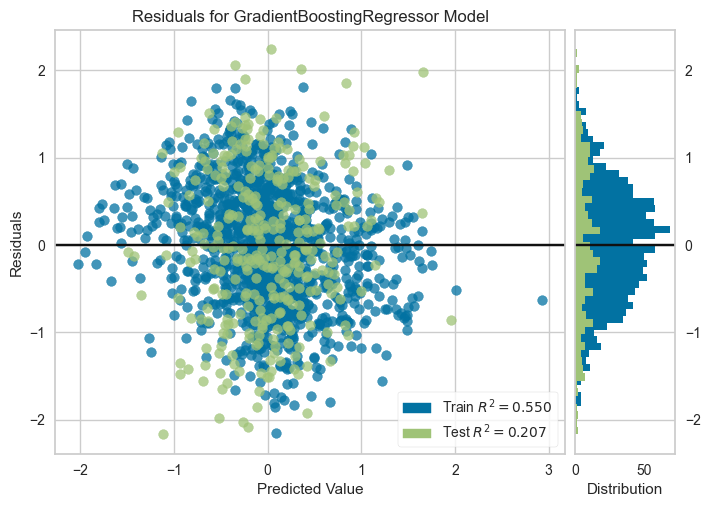

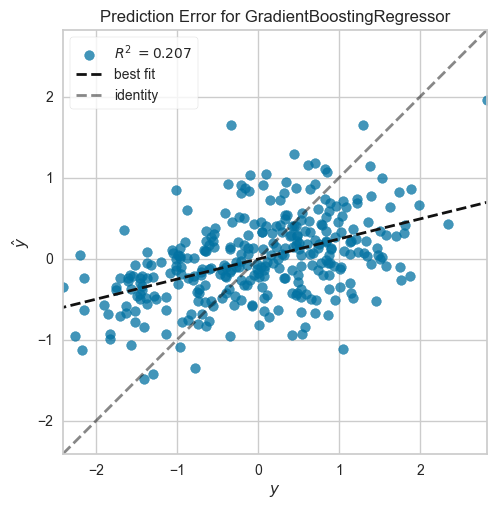

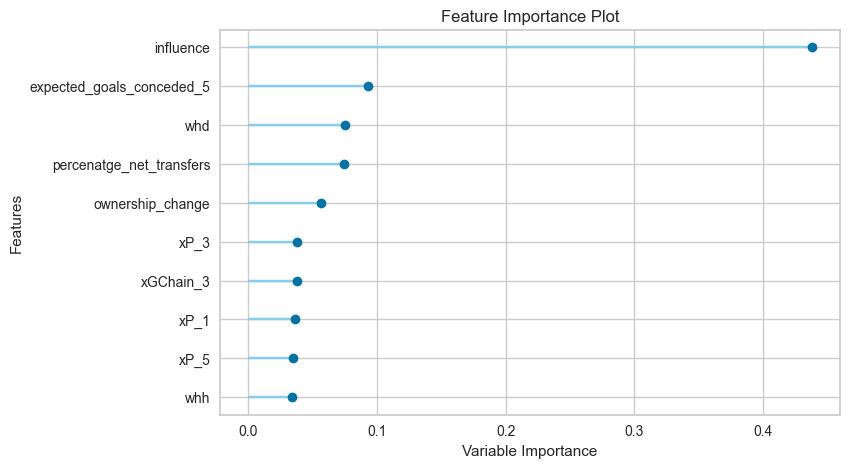

In [42]:
base_g_xgc_model = setup(g_xgc_data, target = 'expected_goals_conceded',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features

                )

base_g_xgc_best = base_g_xgc_model.compare_models(sort='MAE', n_select=1)
print(base_g_xgc_best)

print('Évaluate the model...')
evaluate_model(base_g_xgc_best)

print('Plots...')
plot_model(base_g_xgc_best, plot='residuals')      # Residuals vs. predicted values
plot_model(base_g_xgc_best, plot='error')          # Prediction error plot
plot_model(base_g_xgc_best, plot='feature')        # Feature importance

### Tuned Model


In [43]:
g_xgc_tuned = tune_model(base_g_xgc_best, optimize='MAE')

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.7964,0.9842,0.9921,0.2421,0.4702,1.3950
1,0.7114,0.7336,0.8565,0.2593,0.4100,1.2297
2,0.7265,0.8415,0.9174,0.2562,0.4411,1.6537
3,0.7514,0.7859,0.8865,0.2771,0.4391,1.9377
4,0.6603,0.6640,0.8148,0.2583,0.3709,1.2992
5,0.6929,0.7200,0.8485,0.2008,0.4187,2.4982
6,0.6817,0.7080,0.8414,0.2927,0.4140,1.3584
7,0.6410,0.6335,0.7959,0.2977,0.3866,2.8327
8,0.7249,0.7547,0.8688,0.3074,0.4448,2.3413


Fitting 10 folds for each of 10 candidates, totalling 100 fits


### Save Model


In [44]:
g_xgc_final_model = finalize_model(g_xgc_tuned)
save_model(g_xgc_final_model, './models/g_xgc_final_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'ownership_change',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'clean_sheets_1',
                                              'expected_goals_conceded_1',
                                              'goals_conceded_1', 'ict_index_1',
                                              'influence_1', 'creativity_1'...
                                     transformer=RemoveMulticollinearity(threshold=0.9))),
                 ('feature_selection',
         

## Def


expected_goals_conceded
0.00    79
0.83    75
1.03    57
1.48    56
1.08    47
        ..
9.84     1
6.86     1
6.94     1
3.06     1
3.07     1
Name: count, Length: 386, dtype: int64


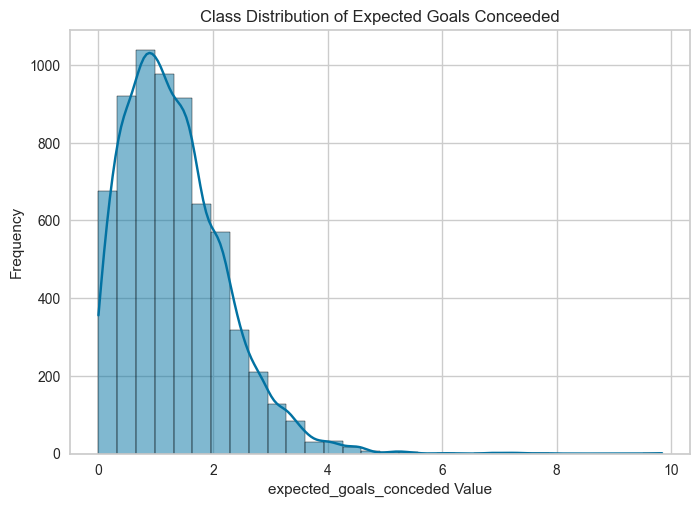

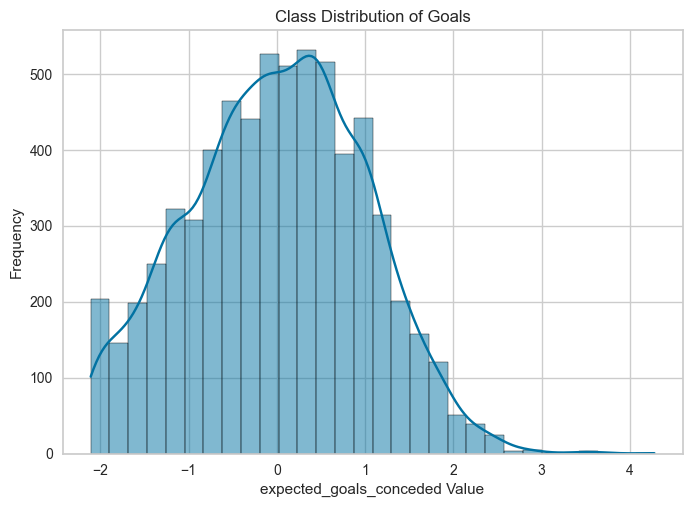

In [45]:
def_xgc_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'DEF')]
def_xgc_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '2')]

def_xgc_data = def_xgc_data[xgc_features]
def_xgc_data_tar = def_xgc_data_tar[xgc_features]

def_xgc_data.reset_index(drop=True, inplace=True)
def_xgc_data.reset_index(drop=True, inplace=True)

def_xgc_data.drop(columns=['position'], inplace=True)
def_xgc_data_tar.drop(columns=['position', 'expected_goals_conceded'], inplace=True)

print(def_xgc_data['expected_goals_conceded'].value_counts())

sns.histplot(data=def_xgc_data, x='expected_goals_conceded', bins=30, kde=True) #countplot(x='expected_goals_conceded', data=def_xgc_data)
plt.title('Class Distribution of Expected Goals Conceeded')
plt.xlabel('expected_goals_conceded Value')
plt.ylabel('Frequency')
plt.show()

pt_def_xgc = PowerTransformer(method='yeo-johnson',  standardize=True)
pt_def_xgc.fit(def_xgc_data[['expected_goals_conceded']])
joblib.dump(pt_def_xgc, './models/pt_def_xgc.pkl')  # Save fitted transformer

def_xgc_data['expected_goals_conceded'] = pt_def_xgc.transform(def_xgc_data[['expected_goals_conceded']])


sns.histplot(data=def_xgc_data, x='expected_goals_conceded', bins=30, kde=True) #countplot(x='expected_goals_conceded', data=def_xgc_data)
plt.title('Class Distribution of Goals')
plt.xlabel('expected_goals_conceded Value')
plt.ylabel('Frequency')
plt.show()


### Base Model


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004227 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6138
[LightGBM] [Info] Number of data points in the train set: 5258, number of used features: 58
[LightGBM] [Info] Start training from score -0.002169


,Description,Value
0,Session id,8884
1,Target,expected_goals_conceded
2,Target type,Regression
3,Original data shape,"(6573, 70)"
4,Transformed data shape,"(6573, 14)"
5,Transformed train set shape,"(5258, 14)"
6,Transformed test set shape,"(1315, 14)"
7,Numeric features,68
8,Rows with missing values,0.0%
9,Preprocess,True


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
xgboost,Extreme Gradient Boosting,0.6909,0.7653,0.8744,0.2410,0.3927,2.3016,0.6460
lightgbm,Light Gradient Boosting Machine,0.6972,0.7585,0.8705,0.2486,0.4143,1.9108,0.9030
et,Extra Trees Regressor,0.7001,0.7660,0.8748,0.2411,0.4221,1.7712,2.1210
rf,Random Forest Regressor,0.7026,0.7709,0.8775,0.2364,0.4239,1.8201,3.9980
gbr,Gradient Boosting Regressor,0.7243,0.8072,0.8982,0.2004,0.4430,1.7977,1.2100
ada,AdaBoost Regressor,0.7778,0.9043,0.9506,0.1052,0.5020,1.4834,0.7900
lr,Linear Regression,0.7824,0.9179,0.9575,0.0924,0.4722,1.7906,1.1440
ridge,Ridge Regression,0.7825,0.9180,0.9576,0.0923,0.4725,1.7914,1.1420
br,Bayesian Ridge,0.7839,0.9197,0.9584,0.0907,0.4757,1.7861,0.4490
en,Elastic Net,0.8059,0.9677,0.9833,0.0429,0.5333,1.3853,0.6690


XGBRegressor(base_score=None, booster='gbtree', callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device='cpu', early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=-1,
             num_parallel_tree=None, random_state=8884, ...)
Évaluate the model...


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

Plots...


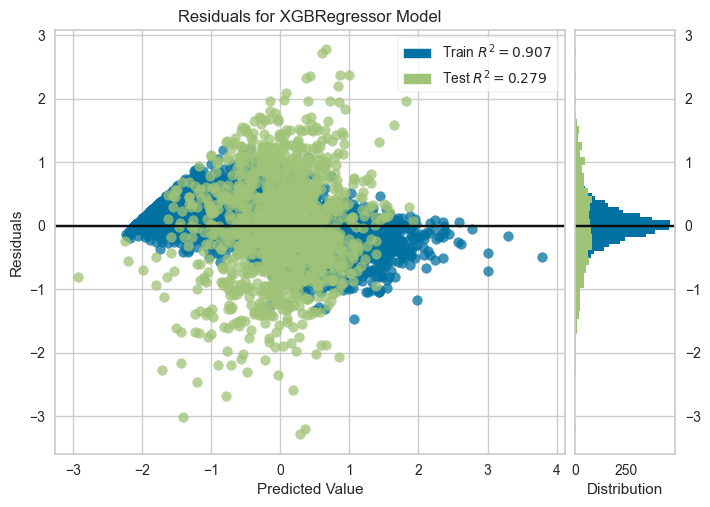

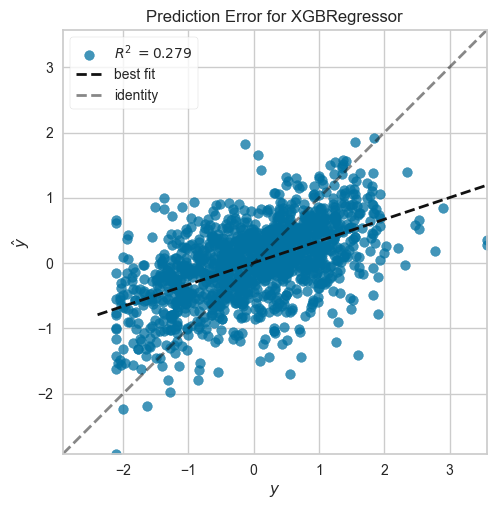

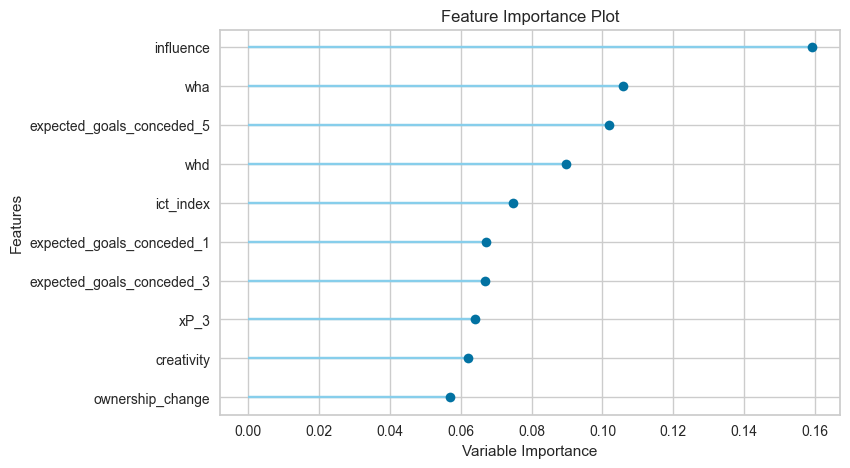

In [ ]:
base_def_xgc_model = setup(def_xgc_data, target = 'expected_goals_conceded',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features

                )

base_def_xgc_best = base_def_xgc_model.compare_models(sort='MAE', n_select=1)
print(base_def_xgc_best)

print('Évaluate the model...')
evaluate_model(base_def_xgc_best)

print('Plots...')
plot_model(base_def_xgc_best, plot='residuals')      # Residuals vs. predicted values
plot_model(base_def_xgc_best, plot='error')          # Prediction error plot
plot_model(base_def_xgc_best, plot='feature')        # Feature importance

### Tuned Model


In [47]:
def_xgc_tuned = tune_model(base_def_xgc_best, optimize='MAE')

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.7058,0.8276,0.9097,0.1765,0.4054,1.6849
1,0.6333,0.6393,0.7996,0.2949,0.3866,3.0163
2,0.6689,0.7095,0.8423,0.2421,0.3910,1.4026
3,0.7070,0.7887,0.8881,0.2906,0.4220,1.9399
4,0.6801,0.7083,0.8416,0.2397,0.3937,2.8476
5,0.6573,0.6671,0.8168,0.3669,0.3928,2.1802
6,0.6715,0.7360,0.8579,0.3316,0.4115,1.6430
7,0.6670,0.7027,0.8383,0.3130,0.4073,1.6266
8,0.6697,0.7163,0.8463,0.3036,0.3978,1.4932


Fitting 10 folds for each of 10 candidates, totalling 100 fits


### Save Model


In [48]:
def_xgc_final_model = finalize_model(base_def_xgc_best)
save_model(def_xgc_final_model, './models/def_xgc_final_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'ownership_change',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'clean_sheets_1',
                                              'expected_goals_conceded_1',
                                              'goals_conceded_1', 'ict_index_1',
                                              'influence_1', 'creativity_1'...
                               feature_types=None, gamma=None, grow_policy=None,
                               importance_type=None,
     

In [49]:
pd.read_csv('./data/2022-23/players/Aaron_Cresswell_457/gw.csv')

,assists,bonus,bps,clean_sheets,creativity,element,expected_assists,expected_goal_involvements,expected_goals,expected_goals_conceded,...,team_a_score,team_h_score,threat,total_points,transfers_balance,transfers_in,transfers_out,value,was_home,yellow_cards
0,0,0,16,0,18.7,457,0.10,0.10,0.00,2.23,...,2,0,0.0,1,0,0,0,50,True,0
1,0,0,14,0,65.8,457,0.21,0.26,0.05,1.36,...,0,1,1.0,2,21509,45044,23535,50,False,0
2,0,0,6,0,38.8,457,0.33,0.38,0.05,1.71,...,2,0,18.0,0,-19414,20572,39986,50,True,1
3,0,0,26,1,5.8,457,0.01,0.06,0.05,0.49,...,1,0,8.0,6,-53162,5437,58599,50,False,0
4,0,0,16,0,1.5,457,0.01,0.01,0.00,0.44,...,1,1,0.0,2,-21500,5184,26684,49,True,0
5,0,0,0,0,0.0,457,0.00,0.00,0.00,0.00,...,1,2,0.0,0,-33385,5180,38565,49,False,0
6,0,0,13,0,31.8,457,0.09,0.13,0.04,0.36,...,0,1,10.0,2,6734,17465,10731,48,False,0
7,0,0,21,1,12.1,457,0.01,0.01,0.00,0.74,...,0,2,0.0,5,17709,30963,13254,48,True,1
8,0,0,20,0,42.8,457,0.12,0.12,0.00,0.70,...,1,3,2.0,2,39911,49989,10078,48,True,0
9,0,1,19,0,47.9,457,0.36,0.36,0.00,0.45,...,1,1,2.0,3,16237,27263,11026,48,False,0
